# Forecasting de Ventas — VIVO Balanced Bites

> **Objetivo:** Pronosticar las ventas semanales de los productos críticos del restaurante universitario VIVO Balanced Bites (sede Principal — Universidad de los Andes), usando datos reales de facturación desde agosto 2024.
>
> **Pipeline:**
> 1. Carga y limpieza de datos de ventas y compras
> 2. Análisis Exploratorio (EDA) + Segmentación de productos (Matriz BCG + Pareto ABC)
> 3. Identificación de productos críticos
> 4. Modelado con **Prophet** (series de tiempo + calendario académico)
> 5. Modelado con **XGBoost** (short-term, basado en lags)
> 6. Modelo **Híbrido** Prophet + XGBoost


## 0. Setup y librerías

Se importan todas las librerías necesarias para el proyecto:
- **pandas / numpy**: manejo y transformación de datos
- **matplotlib / seaborn / plotly**: visualización estática e interactiva
- **sklearn**: métricas de evaluación y preprocesamiento
- **pathlib**: manejo de rutas de archivos multiplataforma


In [1]:
# ── Manejo de datos ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
# ── Visualización ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# ── Machine Learning ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

# ── Utilidades ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')  # Suprimir advertencias de versiones de librerías


## 1. Carga de datos

Se cargan dos tipos de archivos Excel desde OneDrive:

1. **Archivos de productos** (`/Productos/Mes-Año.xlsx`): reportes mensuales con el detalle de cada transacción por producto (ventas y compras). Se leen a partir de la fila 8 (header=7) porque el formato de Siigo tiene encabezados de informe antes de la tabla.

2. **Archivos de factura por lugar** (`/Facturas_lugar/Lugar-Año.xlsx`): facturas agrupadas por punto de venta (Principal y Café Principal). Se leen a partir de la fila 7 (header=6).

Los archivos se almacenan en diccionarios con clave `"Mes-Año"` y `"Lugar-Año"` respectivamente.


In [2]:
from pathlib import Path
import pandas as pd

carpeta = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Productos")
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
años = ["2024", "2025", "2026"]

productos = {}
for año in años:
    for mes in meses:
        archivo = f"{mes}-{año}.xlsx"
        ruta = carpeta / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=7)
            productos[f"{mes}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

carpeta_2 = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Facturas_lugar")
lugares = ["CP", "Principal"]

factura_lugar = {}
for año in años:
    for lugar in lugares:
        archivo = f"{lugar}-{año}.xlsx"
        ruta = carpeta_2 / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=6)
            factura_lugar[f"{lugar}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

print("Productos cargados:", list(productos.keys()))
print("Facturas lugar cargadas:", list(factura_lugar.keys()))


No encontrado: Enero-2024.xlsx
No encontrado: Febrero-2024.xlsx
No encontrado: Marzo-2024.xlsx
No encontrado: Abril-2024.xlsx
No encontrado: Mayo-2024.xlsx
No encontrado: Junio-2024.xlsx
No encontrado: Julio-2024.xlsx
No encontrado: Abril-2026.xlsx
No encontrado: Mayo-2026.xlsx
No encontrado: Junio-2026.xlsx
No encontrado: Julio-2026.xlsx
No encontrado: Agosto-2026.xlsx
No encontrado: Septiembre-2026.xlsx
No encontrado: Octubre-2026.xlsx
No encontrado: Noviembre-2026.xlsx
No encontrado: Diciembre-2026.xlsx
No encontrado: CP-2024.xlsx
No encontrado: Principal-2024.xlsx
No encontrado: CP-2026.xlsx
No encontrado: Principal-2026.xlsx
Productos cargados: ['Agosto-2024', 'Septiembre-2024', 'Octubre-2024', 'Noviembre-2024', 'Diciembre-2024', 'Enero-2025', 'Febrero-2025', 'Marzo-2025', 'Abril-2025', 'Mayo-2025', 'Junio-2025', 'Julio-2025', 'Agosto-2025', 'Septiembre-2025', 'Octubre-2025', 'Noviembre-2025', 'Diciembre-2025', 'Enero-2026', 'Febrero-2026', 'Marzo-2026']
Facturas lugar cargadas: [

## 2. Análisis Exploratorio (EDA)

En esta sección se:
1. Verifica el rango de fechas de cada archivo mensual cargado
2. Se unifican todos los meses en un único DataFrame (`df_total`)
3. Se unen los datos de ventas por establecimiento (`df_place`)
4. Se separan las **facturas de venta** de las **facturas de compra**
5. Se limpian y homologan las columnas para tener un dataset de `ventas` listo para analizar


In [3]:
col_fecha = "Fecha elaboración"

# Verificar rango de fechas de cada archivo cargado
# Esto ayuda a detectar archivos con datos corruptos o fuera del período esperado
for mes, df in productos.items():
    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors="coerce")
    inicio = df[col_fecha].min()
    fin = df[col_fecha].max()
    print(f"{mes}: {inicio.date()} → {fin.date()}")


Agosto-2024: 2024-08-03 → 2024-08-30
Septiembre-2024: 2024-09-06 → 2024-09-24
Octubre-2024: 2024-10-04 → 2024-10-21
Noviembre-2024: 2024-11-25 → 2024-11-25
Diciembre-2024: 2024-12-04 → 2024-12-12
Enero-2025: 2025-01-08 → 2025-01-31
Febrero-2025: 2025-02-01 → 2025-02-28
Marzo-2025: 2025-03-02 → 2025-03-31
Abril-2025: 2025-04-01 → 2025-04-30
Mayo-2025: 2025-05-01 → 2025-05-31
Junio-2025: 2025-06-03 → 2025-06-30
Julio-2025: 2025-07-01 → 2025-07-31
Agosto-2025: 2025-08-04 → 2025-08-31
Septiembre-2025: 2025-09-01 → 2025-09-30
Octubre-2025: 2025-10-01 → 2025-10-31
Noviembre-2025: 2025-11-04 → 2025-11-30
Diciembre-2025: 2025-12-01 → 2025-12-31
Enero-2026: 2026-01-07 → 2026-01-31
Febrero-2026: 2026-02-02 → 2026-02-28
Marzo-2026: 2026-03-02 → 2026-03-27


### Unificar todos los meses en un solo DataFrame

Se concatenan todos los DataFrames mensuales (uno por cada archivo `Mes-Año.xlsx`) en un único DataFrame `df_total`. Se usa `ignore_index=True` para reiniciar el índice y evitar duplicados.


In [4]:
df_total = pd.concat(productos.values(), ignore_index=True)


### Unificar ventas por lugar (establecimiento)

Se combinan los DataFrames de CP (Café Principal) y Principal en un único `df_place`, añadiendo una columna `"Lugar"` que identifica el establecimiento de cada factura. Esto permite filtrar y comparar ventas por punto de venta.


In [5]:
# Extraer los DataFrames de cada establecimiento
CP_df = factura_lugar["CP-2025"]
Principal_df = factura_lugar["Principal-2025"]

# Agregar columna de identificación antes de unir
# (necesario para saber de qué local proviene cada fila después del concat)
CP_df["Lugar"] = "CP"
Principal_df["Lugar"] = "Principal"

# Unificar en un solo DataFrame con todos los establecimientos
df_place = pd.concat([CP_df, Principal_df], ignore_index=True)


### Comparar columnas entre los dos DataFrames

Se identifican qué columnas existen solo en `df_total` (por producto), solo en `df_place` (por lugar) y cuáles son comunes. Esto ayuda a entender qué información aporta cada fuente y cómo unirlas si es necesario.


In [6]:
col1 = set(df_total.columns)   # columnas del df por producto
col2 = set(df_place.columns)   # columnas del df por lugar

# Columnas exclusivas de cada fuente y columnas comunes
print("Solo en df_total (por producto):", col1 - col2)
print("Solo en df_place (por lugar):", col2 - col1)
print("En ambos (posibles llaves de join):", col2 & col1)


Solo en df_total (por producto): {'Identificación', 'Nombre tercero', 'Impuesto cargo', 'Nombre vendedor', 'Cargo en totales', 'Fecha vencimiento', 'Forma pago', 'Número comprobante', 'Sucursal', 'Correo electrónico', 'Consecutivo', 'Cantidad', 'Valor Impuesto Cargo 2', 'Valor desc.', 'Tipo clasificación', 'Código', 'Fecha modificación', 'Impuesto Cargo 2', 'Valor unitario', 'Base retención (ICA/IVA)', 'Descuento en totales', 'Centro costo', 'Tipo de registro', 'Tasa de cambio', 'Impuesto retención', 'Fecha elaboración', 'Observaciones', 'Fecha creación', 'Nombre contacto', 'Bodega', 'Referencia fábrica', 'Identificación Vendedor', 'Valor Impuesto Cargo', 'Tipo transacción', 'Base AIU', 'Factura proveedor', 'Nombre', 'Valor Impuesto Retención'}
Solo en df_place (por lugar): {'Fecha y hora', 'Estado', 'Turno', 'Efectivo', 'Tipo de comprobante', 'Lugar', 'Pagos en línea', 'Crédito', 'Otros', 'Vendedor', 'Nro. de comprobante', 'Nro. de identificación', 'Cliente', 'Tarjetas'}
En ambos (pos

### Separar ventas y compras, y seleccionar columnas relevantes

Los archivos de Siigo mezclan facturas de **venta** y de **compra** en la misma hoja. Aquí se separan:
- `df_ventas_producto`: solo filas con `"Tipo transacción" == "Factura de venta"`
- `df_compras_producto`: solo filas con `"Tipo transacción" == "Factura de compra"`

Adicionalmente, se asigna el **establecimiento** según el número de comprobante:
- `FV-1` → Principal | `FV-4` → CP | `FV-2/FV-3` → Eventos


In [7]:
#Ventas
df_ventas_producto=df_total[df_total["Tipo transacción"]=="Factura de venta"]
df_ventas_producto = df_ventas_producto.reset_index(drop=True)

variables_iniciales=["Consecutivo","Fecha creación","Tipo de registro","Tipo clasificación","Código","Nombre","Nombre vendedor",\
                     "Cantidad","Valor unitario","Valor Impuesto Cargo","Total","Forma pago","Número comprobante"]
df_ventas_producto_filtrado=df_ventas_producto[variables_iniciales]

df_ventas_producto_filtrado['Establecimiento'] = df_ventas_producto_filtrado['Número comprobante'].map({'FV-1': 'Principal',"FV-2":"Eventos","FV-3":"Eventos",'FV-4': 'CP'})

#Compras
df_compras_producto=df_total[df_total["Tipo transacción"]=="Factura de compra"]
variables_compras=["Consecutivo","Factura proveedor","Identificación","Nombre tercero","Fecha creación","Fecha modificación","Fecha elaboración","Nombre contacto"\
    ,"Tipo de registro","Tipo clasificación","Código","Nombre","Cantidad","Valor unitario","Total","Forma pago","Fecha vencimiento"]

df_compras_producto_filtrado=df_compras_producto[variables_compras]


### Convertir columnas de fecha a tipo `datetime`

Las fechas vienen en formato de texto `'DD/MM/YYYY'` desde Excel. Se convierten a tipo `datetime` de pandas para poder hacer operaciones temporales (agrupar por mes, semana, etc.).


In [8]:

df_ventas_producto_filtrado['Fecha creación'] = pd.to_datetime(df_ventas_producto_filtrado
                                                               ['Fecha creación'], format='%d/%m/%Y')

fechas = ["Fecha creación", "Fecha modificación", "Fecha elaboración", "Fecha vencimiento"]
df_compras_producto_filtrado[fechas] = df_compras_producto_filtrado[fechas].apply(
    pd.to_datetime, format='%d/%m/%Y'
)


### Propagar la forma de pago y limpiar filas vacías

En Siigo, la forma de pago (efectivo, tarjeta, etc.) aparece solo en la **primera fila** de cada factura. Las filas siguientes (que corresponden a cada ítem de la factura) tienen ese campo vacío.

- `.bfill()` propaga el valor hacia abajo para que cada ítem tenga su forma de pago
- `.dropna(subset=["Código"])` elimina las filas que solo eran encabezados de pago y no tienen producto asociado


In [9]:
#Poner el tipo de transacción de cda fila 
df_ventas_producto_filtrado["Forma pago"]=df_ventas_producto_filtrado["Forma pago"].bfill()
df_compras_producto_filtrado["Forma pago"]=df_compras_producto_filtrado["Forma pago"].bfill()
#Eliminar las filas que hacian referencia al metodo de pago
df_ventas_producto_filtrado.dropna(subset=["Código"],inplace=True)
df_compras_producto_filtrado.dropna(subset=["Código"],inplace=True)


### Eliminar columnas innecesarias

Se eliminan `"Tipo de registro"` y `"Tipo clasificación"` porque son columnas internas de Siigo que no aportan información útil para el análisis de ventas.


In [10]:
df_ventas_producto_filtrado.drop(columns=["Tipo de registro","Tipo clasificación"],inplace=True)


### Dataset final de ventas

Se renombra `"Fecha creación"` a `"Fecha"` para simplificar el acceso. El DataFrame `ventas` queda con las columnas clave: **Fecha, Nombre del producto, Cantidad, Total, Establecimiento, Forma de pago** y **Número de comprobante**.


In [11]:
# Alias más corto para facilitar el uso en el resto del notebook
ventas = df_ventas_producto_filtrado

# Renombrar "Fecha creación" → "Fecha" para simplificar acceso
ventas.rename(columns={"Fecha creación": "Fecha"}, inplace=True)

ventas  # Mostrar el DataFrame final de ventas


,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento
0,401.0,2024-08-30,11,Sándwich o pockets (Mini chef),Tatiana Perez,1.0,12962.96,1037.04,14000.0,Tarjeta Débito,FV-1,Principal
1,401.0,2024-08-30,28,Ensalada Pollo miel mostaza Mediana,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal
2,401.0,2024-08-30,38,Arma tu plato mediano (18k),Tatiana Perez,1.0,20370.37,1629.63,22000.0,Tarjeta Débito,FV-1,Principal
3,401.0,2024-08-30,66,Pancakes chocolate,Tatiana Perez,1.0,8888.89,711.11,9600.0,Tarjeta Débito,FV-1,Principal
5,402.0,2024-08-30,B0002,Agua cristal,Tatiana Perez,1.0,2777.78,222.22,3000.0,Efectivo,FV-1,Principal
...,...,...,...,...,...,...,...,...,...,...,...,...
34767,990.0,2026-03-02,56543553,Empanada,Juan Jose Yara Vallejo,2.0,5000.00,0.00,10000.0,Efectivo,FV-4,CP
34769,991.0,2026-03-02,26,Ensalada Chefsito Mediana,Juan Jose Yara Vallejo,1.0,21296.30,1703.70,23000.0,Tarjeta Débito,FV-4,CP
34771,992.0,2026-03-02,53,Hatsu blanco 400ml,Juan Jose Yara Vallejo,1.0,7407.41,592.59,8000.0,Tarjeta Débito,FV-4,CP
34773,993.0,2026-03-02,79,Americano Mediano,Juan Jose Yara Vallejo,1.0,5000.00,0.00,5000.0,Efectivo,FV-4,CP


### Cargar datos de compras

Las compras se cargan desde un CSV pre-procesado (`compras.csv`) que ya tiene el formato correcto con columna `Periodo` y `Total`. Este archivo se generó previamente a partir de los datos de Siigo.


In [12]:
compras=compras = pd.read_csv('compras.csv')


### Agregar columna de período mensual

Se agrega la columna `"Periodo"` con formato `YYYY-MM` (tipo `Period`) para agrupar las ventas por mes. Esto permite hacer resúmenes mensuales y gráficos de tendencia en el tiempo.


In [13]:
ventas["Periodo"] = pd.to_datetime(ventas["Fecha"]).dt.to_period("M")


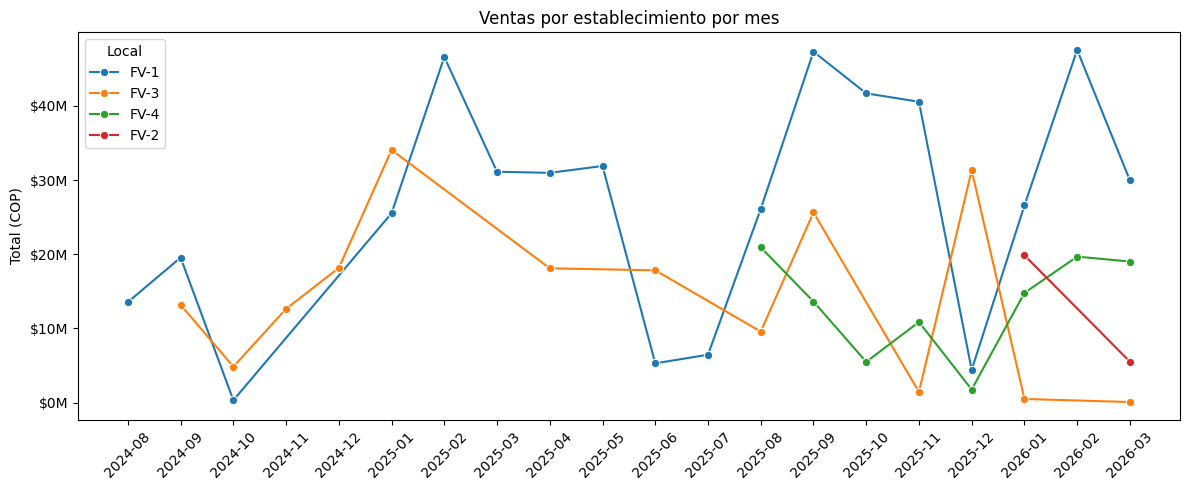

In [14]:

resumen = (
    ventas
    .groupby(["Periodo", "Número comprobante"])["Total"]
    .sum()
    .reset_index()
)

resumen["Periodo"] = resumen["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resumen,
    x="Periodo",
    y="Total",
    hue="Número comprobante",
    marker="o"              # ← agrega puntos en cada mes
)
plt.xticks(rotation=45)
plt.title("Ventas por establecimiento por mes")
plt.ylabel("Total (COP)")
plt.xlabel("")
plt.legend(title="Local")  # ← título más claro en la leyenda

# Formato en millones en el eje Y
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()


### Ventas por establecimiento y mes (gráfico de líneas)

Se calcula el total de ventas agrupando por `Periodo` y `Número comprobante` (que identifica el establecimiento). El gráfico de líneas muestra la evolución mensual de cada punto de venta por separado, permitiendo detectar cuál aporta más y si hay patrones estacionales diferenciados.


In [15]:
import pandas as pd
import plotly.express as px

# 1. Resumen de ventas
resumen_mes = (
    ventas
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)

# Convertir a string es vital para que no lo trate como fecha continua
resumen_mes["Periodo"] = resumen_mes["Periodo"].astype(str)

# 2. Gráfico interactivo
fig = px.bar(
    resumen_mes, 
    x="Periodo", 
    y="Total",
    title="Análisis de Ventas por Periodo",
    labels={"Total": "Monto ($)", "Periodo": "Mes"},
    text_auto='.2s', 
    color_discrete_sequence=["steelblue"]
)

# 3. Personalización estética (Aquí forzamos que aparezcan todos los meses con datos)
fig.update_layout(
    xaxis_tickangle=-45,
    # ESTA LÍNEA ES LA QUE ELIMINA LOS HUECOS VACÍOS COMO DICIEMBRE:
    xaxis_type='category', 
    yaxis_tickformat="$.2s", # Cambiado a .2s para que el eje diga $80M en lugar de $80,000,000
    hovermode="x unified",
    template="plotly_white"
)

# 4. Mostrar el gráfico
fig.show()


### Tendencia general de ventas (gráfico interactivo)

Gráfico de barras interactivo con Plotly que muestra el **total de ventas consolidado por mes** (todos los establecimientos juntos). Se usa `xaxis_type='category'` para evitar que Plotly muestre meses sin datos como huecos en el eje X.


In [16]:
import plotly.express as px

# 1. Preparación (Asegúrate de convertir el periodo a texto para evitar los huecos)
resumen_compras_mes = (
    compras
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)
resumen_compras_mes["Periodo"] = resumen_compras_mes["Periodo"].astype(str)

# 2. Gráfico
fig = px.bar(
    resumen_compras_mes, 
    x="Periodo", 
    y="Total",
    title="Total Compras por Periodo",
    color_discrete_sequence=["#CD5C5C"] # Rojo similar al de tu imagen
)

# 3. El truco para quitar los huecos y poner el formato $18M
fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    # ESTA LÍNEA QUITA LOS HUECOS:
    xaxis_type='category', 
    # ESTA LÍNEA PONE EL FORMATO $18M:
    yaxis_tickformat="$.2s", 
    hovermode="x unified"
)

# Personalizar el texto al pasar el mouse
fig.update_traces(
    hovertemplate="<b>Periodo:</b> %{x}<br><b>Total:</b> $%{y:,.0f}"
)

fig.show()


### Tendencia de compras (gráfico interactivo)

Mismo análisis pero para las **compras** (costo de insumos). Comparar este gráfico con el de ventas permite identificar si el margen se mantiene estable o hay meses donde el costo sube desproporcionalmente.


In [17]:
ventas_compras = resumen_mes.merge(
    resumen_compras_mes, 
    on="Periodo", 
    how="outer",
    suffixes=("_ventas", "_compras")
)

ventas_compras = ventas_compras.fillna(0)
ventas_compras["Utilidad"] = ventas_compras["Total_ventas"] - ventas_compras["Total_compras"]
ventas_compras = ventas_compras.sort_values("Periodo").reset_index(drop=True)

print(ventas_compras[["Periodo", "Total_ventas", "Total_compras", "Utilidad"]])


    Periodo  Total_ventas  Total_compras     Utilidad
0   2024-08   13552500.00     17591988.0  -4039488.00
1   2024-09   32727310.00            0.0  32727310.00
2   2024-10    5174300.00            0.0   5174300.00
3   2024-11   12644600.00            0.0  12644600.00
4   2024-12   18159161.00            0.0  18159161.00
5   2025-01   59576997.17      4249653.0  55327344.17
6   2025-02   46580484.50      3089645.0  43490839.50
7   2025-03   31114572.00      3692100.0  27422472.00
8   2025-04   49071040.40      4949213.0  44121827.40
9   2025-05   31888620.00      5764664.0  26123956.00
10  2025-06   23134199.26      2863814.0  20270385.26
11  2025-07    6460500.00      6150784.0    309716.00
12  2025-08   56603715.00      5242819.0  51360896.00
13  2025-09   86547085.00      9624248.0  76922837.00
14  2025-10   47174155.00      4496786.0  42677369.00
15  2025-11   52863172.00      5109383.0  47753789.00
16  2025-12   37505122.90      2227879.0  35277243.90
17  2026-01   61709036.00   

### Calcular utilidad bruta por mes

Se hace un `merge` entre ventas y compras por período, y se calcula la **utilidad bruta** = Ventas - Compras. Los valores negativos indican meses donde los costos superaron los ingresos (p.ej., meses de cierre o de compras anticipadas).

> ⚠️ Esta es una utilidad bruta simplificada. No incluye costos fijos (arriendo, nómina, servicios).


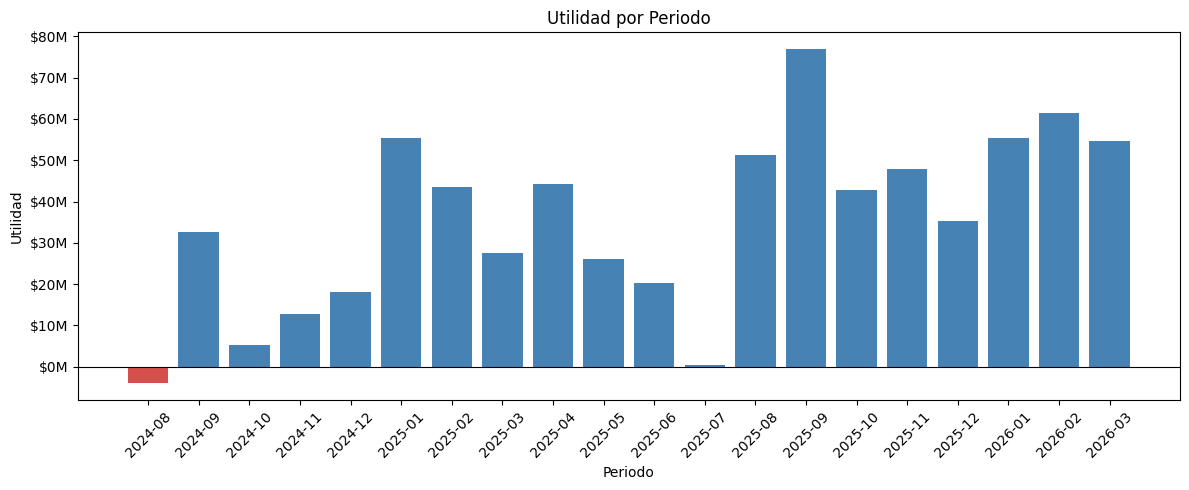

In [18]:
plt.figure(figsize=(12, 5))
plt.bar(ventas_compras["Periodo"], ventas_compras["Utilidad"], 
        color=["#d5504b" if x < 0 else "steelblue" for x in ventas_compras["Utilidad"]])
plt.title("Utilidad por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Utilidad")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


In [19]:
# Filtrar solo el establecimiento Principal desde 2024
# (se excluye CP y Eventos para analizar el local principal de forma aislada)
ventas_p = (
    ventas[
        (ventas["Establecimiento"] == "Principal") &
        (ventas["Fecha"] >= "2024-01-01")
    ]
    .sort_values("Fecha", ascending=True)
    .reset_index()
)




### Limpiar nombres de cada producto

In [20]:

def limpiar_nombre_final(text):
    if pd.isna(text): return text
    
    # 1. Definir qué queremos ELIMINAR (Tamaños, pesos, precios, paréntesis)
    # Eliminamos: (21k), (18k), 9oz, 14oz, Mediana, Grande, Mediano, Veggie
    patrones_a_remover = [
        r'\(.*\)',          # Todo lo que esté entre paréntesis
        r'\d+k',            # Precios tipo 18k, 21k
        r'\d+oz',           # Pesos tipo 9oz, 14oz
        r'Mediana', r'Mediano', r'Grande', r'Veggie', # Palabras de tamaño
        r'400ml', r'600ml', r'250ml', r'450ml'         # Volúmenes de bebidas
    ]
    
    temp_name = text
    for patron in patrones_a_remover:
        temp_name = re.sub(patron, '', temp_name, flags=re.IGNORECASE)
    
    # 2. Limpieza de espacios y estandarización
    temp_name = " ".join(temp_name.split()).strip()
    
    # 3. Mapeo de excepciones (Casos que Regex no limpia solo)
    mapeo_especifico = {
        'Hatsu amarillo': 'Hatsu Amarillo',
        'Chocolate caliente': 'Chocolate Caliente',
        'Pastel de pollo': 'Pastel de Pollo',
        'Agua cristal': 'Agua sin Gas',
        'Agua sin gas cristal': 'Agua sin Gas',
        'Agua con gas cristal': 'Agua con Gas',
        'Soda rosada': 'Soda Hatsu Rosada',
        'Parfaits': 'Parfait Frutos Rojos',
        'Parfaits frutos rojos': 'Parfait Frutos Rojos'
    }
    
    # Retornar el nombre mapeado o el limpio con la primera letra en mayúscula
    nombre_limpio = mapeo_especifico.get(temp_name, temp_name)
    return nombre_limpio.capitalize() if len(nombre_limpio) > 0 else text

# --- APLICACIÓN EN TU DATAFRAME ---

# Crear la columna de apoyo 'name'
ventas_p['name'] = ventas_p['Nombre'].apply(limpiar_nombre_final)

# Reemplazar la columna Original por la limpia
ventas_p['Nombre'] = ventas_p['name']

# Eliminar la columna temporal 'name' para que el DF quede impecable
ventas_p = ventas_p.drop(columns=['name'])

# Visualizar el resultado
ventas_p.head(20)


,index,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento,Periodo
0,1143,10.0,2024-08-05,17,Bowl colombianito,Juan Jose Yara Vallejo,1.0,19166.67,1533.33,20700.0,Efectivo,FV-1,Principal,2024-08
1,1141,1.0,2024-08-05,18,Bowl pollo tostada,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
2,1145,11.0,2024-08-05,17,Bowl colombianito,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
3,1146,11.0,2024-08-05,19,Bowl pollo tostada,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
4,1148,12.0,2024-08-05,17,Bowl colombianito,Juan Jose Yara Vallejo,1.0,21296.30,1703.70,23000.0,Tarjeta Débito,FV-1,Principal,2024-08
5,1151,13.0,2024-08-05,24,Ensalada kale cesar,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
6,1152,13.0,2024-08-05,37,Ensalada italianísima,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
7,1154,2.0,2024-08-05,26,Ensalada chefsito,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal,2024-08
8,1149,12.0,2024-08-05,39,Arma tu plato,Juan Jose Yara Vallejo,1.0,19444.44,1555.56,21000.0,Tarjeta Débito,FV-1,Principal,2024-08
9,1158,4.0,2024-08-05,39,Arma tu plato,Juan Jose Yara Vallejo,1.0,22222.22,1777.78,24000.0,Tarjeta Débito,FV-1,Principal,2024-08


### seleccionar solo las columnas necesarias

In [21]:
# Seleccionar solo las columnas necesarias para el análisis de productos
dataset_p = ventas_p[["Fecha", "Nombre", "Cantidad", "Total"]]


## 2.1 Segmentación de productos — Matriz BCG

Se analiza el catálogo de productos del **establecimiento Principal** (desde enero 2024) para identificar cuáles son los más importantes para el negocio.

Para cada producto se calcula:
- **transacciones**: número de veces que fue vendido
- **cantidad_total**: unidades totales vendidas
- **precio_promedio**: precio por unidad
- **Plata generada**: ingresos totales

Luego se clasifica cada producto en un cuadrante de la **Matriz BCG adaptada**:
| Cuadrante | Criterio |
|---|---|
| **ESTRELLA** | Alto volumen Y alta plata generada |
| **PREMIUM** | Bajo volumen PERO alta plata (producto caro) |
| **GANCHO** | Alto volumen PERO baja plata (producto barato/de conveniencia) |
| **BAJO DESEMPEÑO** | Bajo volumen Y baja plata |

Los cortes se hacen en la **mediana** de cada métrica.


In [22]:
# Calcular métricas de desempeño por producto
# Se usa groupby + apply para calcular estadísticas de cada producto en una sola pasada
info_productos = dataset_p.groupby("Nombre").apply(lambda x: pd.Series({
    "transacciones":    x["Nombre"].count(),              # nº de veces que se vendió
    "cantidad_total":   x["Cantidad"].sum(),              # unidades totales vendidas
    "precio_promedio":  x["Total"].sum() / x["Cantidad"].sum(),  # precio promedio ponderado
    "Plata generada":   x["Total"].sum()                  # ingresos totales
})).sort_values("transacciones", ascending=False)


In [23]:
# Definimos los puntos de corte
corte_x = info_productos["cantidad_total"].median()
corte_y = info_productos["Plata generada"].median()

# Función para asignar el color/categoría
def clasificar(row):
    if row["cantidad_total"] >= corte_x and row["Plata generada"] >= corte_y:
        return "ESTRELLA (Alto Vol / Alto $)"
    elif row["cantidad_total"] < corte_x and row["Plata generada"] >= corte_y:
        return "PREMIUM (Bajo Vol / Alto $)"
    elif row["cantidad_total"] >= corte_x and row["Plata generada"] < corte_y:
        return "GANCHO (Alto Vol / Bajo $)"
    else:
        return "BAJO DESEMPEÑO"

# Aplicamos la lógica al DataFrame
info_productos["Categoria_Matriz"] = info_productos.apply(clasificar, axis=1)

# ── Conteo por cuadrante ──────────────────────────────────────────────────────
conteos = info_productos["Categoria_Matriz"].value_counts()
n_estrella = conteos.get("ESTRELLA (Alto Vol / Alto $)", 0)
n_premium  = conteos.get("PREMIUM (Bajo Vol / Alto $)", 0)
n_gancho   = conteos.get("GANCHO (Alto Vol / Bajo $)", 0)
n_bajo     = conteos.get("BAJO DESEMPEÑO", 0)

import plotly.express as px

fig = px.scatter(
    info_productos.reset_index(), 
    x="cantidad_total", 
    y="Plata generada",
    color="Categoria_Matriz",
    color_discrete_map={
        "ESTRELLA (Alto Vol / Alto $)": "#2ecc71",
        "PREMIUM (Bajo Vol / Alto $)": "#3498db",
        "GANCHO (Alto Vol / Bajo $)": "#f1c40f",
        "BAJO DESEMPEÑO": "#e74c3c"
    },
    hover_name="Nombre",
    log_x=True, 
    log_y=True,
    hover_data=["precio_promedio", "transacciones"],
    title="Dashboard de Estrategia de Productos",
    template="plotly_white"
)

fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='white')))
fig.add_vline(x=corte_x, line_dash="dot", line_color="gray", opacity=0.5)
fig.add_hline(y=corte_y, line_dash="dot", line_color="gray", opacity=0.5)

# ── Anotaciones en las 4 esquinas ─────────────────────────────────────────────
anotaciones = [
    dict(x=0.99, y=0.99, text=f"<b> {n_estrella} productos</b>",
         font=dict(color="#27ae60", size=12),
         xanchor="right", yanchor="top"),
    dict(x=0.01, y=0.99, text=f"<b> {n_premium} productos</b>",
         font=dict(color="#2980b9", size=12),
         xanchor="left", yanchor="top"),
    dict(x=0.99, y=0.01, text=f"<b> {n_gancho} productos</b>",
         font=dict(color="#d4ac0d", size=12),
         xanchor="right", yanchor="bottom"),
    dict(x=0.01, y=0.01, text=f"<b> {n_bajo} productos</b>",
         font=dict(color="#c0392b", size=12),
         xanchor="left", yanchor="bottom"),
]

for a in anotaciones:
    fig.add_annotation(
        x=a["x"], y=a["y"],
        text=a["text"],
        showarrow=False,
        font=a["font"],
        xref="paper", yref="paper",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="lightgray",
        borderwidth=1,
        borderpad=6,
        xanchor=a["xanchor"],
        yanchor=a["yanchor"],
    )

fig.update_layout(
    legend_title_text='Categoría de Negocio',
    font=dict(family="Verdana", size=12)
)

fig.show()


In [24]:
info_productos=info_productos.reset_index()


In [25]:
ventas_p["Nombre"].unique()


array(['Bowl colombianito', 'Bowl pollo tostada', 'Ensalada kale cesar',
       'Ensalada italianísima', 'Ensalada chefsito', 'Arma tu plato',
       'Bowl lomo alto', 'Sándwich o pockets', 'Parfait frutos rojos',
       'Ensalada pollo pesto', 'Agua sin gas', 'Bowl pasta buona',
       'Hatsu amarillo', 'Ensalada pollo miel mostaza', 'Hatsu blanco',
       'Soda hatsu rosada', 'Sándwich felix carne', 'Sándwich becha',
       'Sándwich felix pollo', 'Leche de almendras', 'Pancakes chocolate',
       'Tostadas francesas fit', 'Sándwich romano', 'Soda lucy pink',
       'Sándwich verde', 'Sándwich criollo', 'Quiche de pollo',
       'Parfait vivir', 'Pastel de carne', 'Smoothie se vivo',
       'Smoothie reactívate con vivo', 'Capuchino',
       'Smoothie fresa banano', 'Smoothie banano nuez', 'Ensalada ligera',
       'Sándwich indio', 'Parfait frutos amarillos',
       'Agua sin gas cristal', 'Hatsu azul', 'Hatsu rojo',
       'Tostadas francesas clasica', 'Pancakes frutos rojos',
    

## 2.2 Análisis ABC — Pareto por plata generada (productos Estrella)

Dentro del segmento **ESTRELLA**, se aplica la regla de Pareto (80/20) ordenando los productos por `Plata generada`:
- **Clase A** (verde): el 80% de los ingresos — los más críticos
- **Clase B** (azul): el siguiente 15%
- **Clase C** (gris): el restante 5%

El gráfico de Pareto tiene barras (ingresos) en el eje izquierdo y la curva acumulada en el eje derecho.


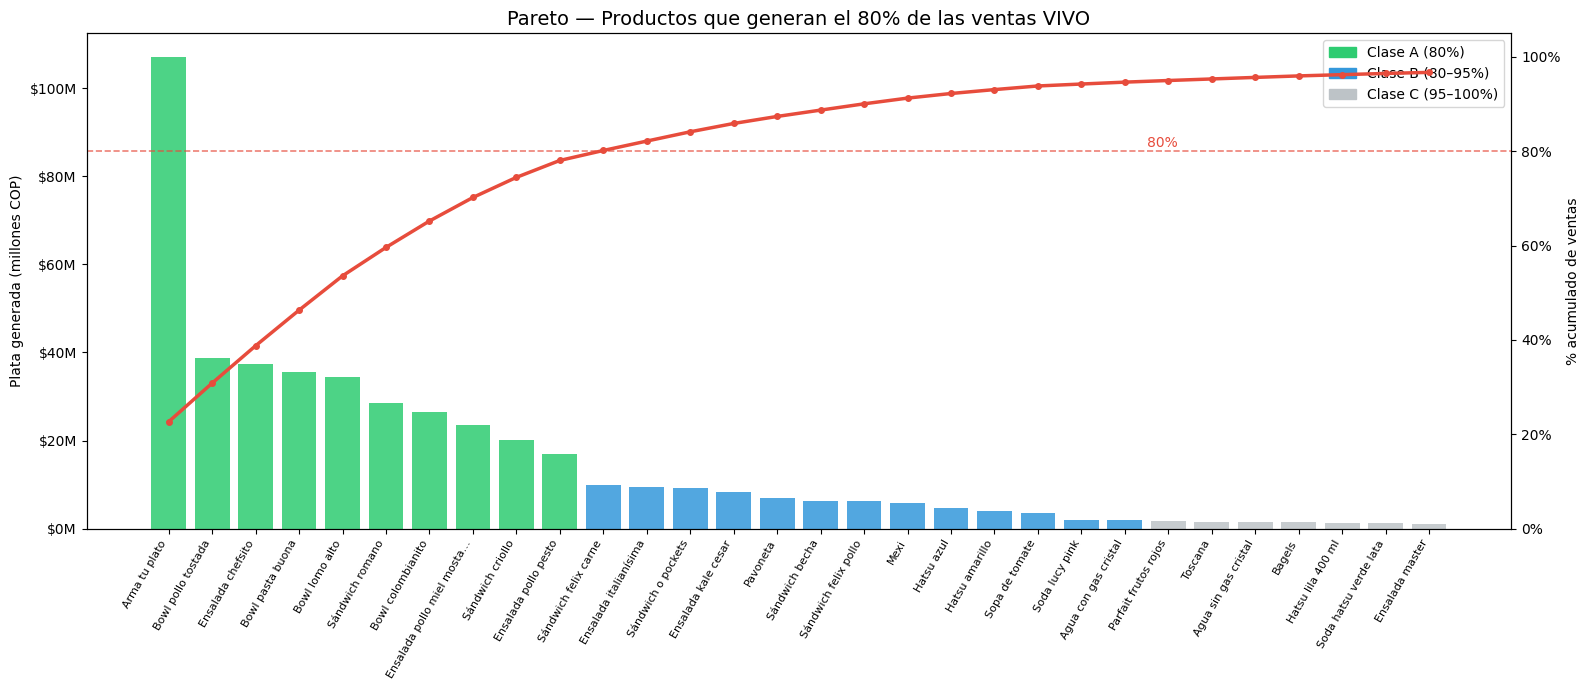


Resumen ABC:
Clase_ABC
C    44
B    13
A    10
Name: count, dtype: int64

Productos Clase A: 10
Plata generada Clase A: $368,812,551


In [26]:
# ── PASO 1: ordenar PRIMERO ───────────────────────────────────────
info_productos=info_productos[info_productos["Categoria_Matriz"]=="ESTRELLA (Alto Vol / Alto $)"]
info_productos = info_productos.sort_values('Plata generada', ascending=False).reset_index(drop=True)



# ── PASO 2: calcular pct DESPUÉS de ordenar ───────────────────────

total = info_productos['Plata generada'].sum()

info_productos['pct']      = info_productos['Plata generada'] / total

info_productos['pct_acum'] = info_productos['pct'].cumsum()



# ── PASO 3: clasificar ABC ────────────────────────────────────────

condiciones = [

    info_productos['pct_acum'] <= 0.80,

    info_productos['pct_acum'] <= 0.95,

]

info_productos['Clase_ABC'] = np.select(condiciones, ['A', 'B'], default='C')



# ── PASO 4: graficar ──────────────────────────────────────────────

n_mostrar = min(30, len(info_productos))

df_plot   = info_productos.head(n_mostrar)



colores = df_plot['Clase_ABC'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})



fig, ax1 = plt.subplots(figsize=(16, 7))



# Barras — plata generada

ax1.bar(range(n_mostrar), df_plot['Plata generada'] / 1_000_000, color=colores, alpha=0.85)

ax1.set_ylabel('Plata generada (millones COP)')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))



# Línea acumulada (eje derecho)

ax2 = ax1.twinx()

ax2.plot(range(n_mostrar), df_plot['pct_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)

ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)

ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de ventas')

ax2.set_ylim(0, 105)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))



# Etiquetas eje X

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]

ax1.set_xticks(range(n_mostrar))

ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)



# Leyenda

leyenda = [

    Patch(color='#2ecc71', label='Clase A (80%)'),

    Patch(color='#3498db', label='Clase B (80–95%)'),

    Patch(color='#bdc3c7', label='Clase C (95–100%)'),

]

ax1.legend(handles=leyenda, loc='upper right')



plt.title('Pareto — Productos que generan el 80% de las ventas VIVO', fontsize=14)

plt.tight_layout()

plt.show()



print(f"\nResumen ABC:")

print(info_productos['Clase_ABC'].value_counts())

print(f"\nProductos Clase A: {(info_productos['Clase_ABC'] == 'A').sum()}")

print(f"Plata generada Clase A: ${info_productos[info_productos['Clase_ABC']=='A']['Plata generada'].sum():,.0f}")


### Mostar datos detallados de cada producto CLASE A en plata generada

In [27]:
# 1. Extraer los productos que quedaron clasificados como 'A'
productos_clase_a = info_productos[info_productos['Clase_ABC'] == 'A'].copy()

# 2. Imprimir el encabezado con el conteo
print(f" ENFOQUE ESTRATÉGICO: PRODUCTOS CLASE A ({len(productos_clase_a)} ítems)")
print("Estos productos generan el 80% de tus ingresos estrella.")
print("=" * 95)

# 3. Mostrar la tabla formateada
# Seleccionamos las columnas que dan contexto: Nombre, Plata y el acumulado
columnas_finales = ['Nombre', 'Plata generada', 'pct', 'pct_acum']

print(productos_clase_a[columnas_finales].to_string(
    index=False,
    formatters={
        'Plata generada': lambda x: f"${x:,.0f}",
        'pct': lambda x: f"{x*100:.1f}%",
        'pct_acum': lambda x: f"{x*100:.1f}%"
    }
))

print("=" * 95)
print(f" TOTAL VENTA CLASE A: ${productos_clase_a['Plata generada'].sum():,.0f}")


 ENFOQUE ESTRATÉGICO: PRODUCTOS CLASE A (10 ítems)
Estos productos generan el 80% de tus ingresos estrella.
                     Nombre Plata generada   pct pct_acum
              Arma tu plato   $107,097,501 22.7%    22.7%
         Bowl pollo tostada    $38,669,700  8.2%    30.8%
          Ensalada chefsito    $37,435,500  7.9%    38.8%
           Bowl pasta buona    $35,651,850  7.5%    46.3%
             Bowl lomo alto    $34,361,900  7.3%    53.6%
            Sándwich romano    $28,473,750  6.0%    59.6%
          Bowl colombianito    $26,451,300  5.6%    65.2%
Ensalada pollo miel mostaza    $23,568,450  5.0%    70.2%
           Sándwich criollo    $20,143,600  4.3%    74.5%
       Ensalada pollo pesto    $16,959,000  3.6%    78.1%
 TOTAL VENTA CLASE A: $368,812,551


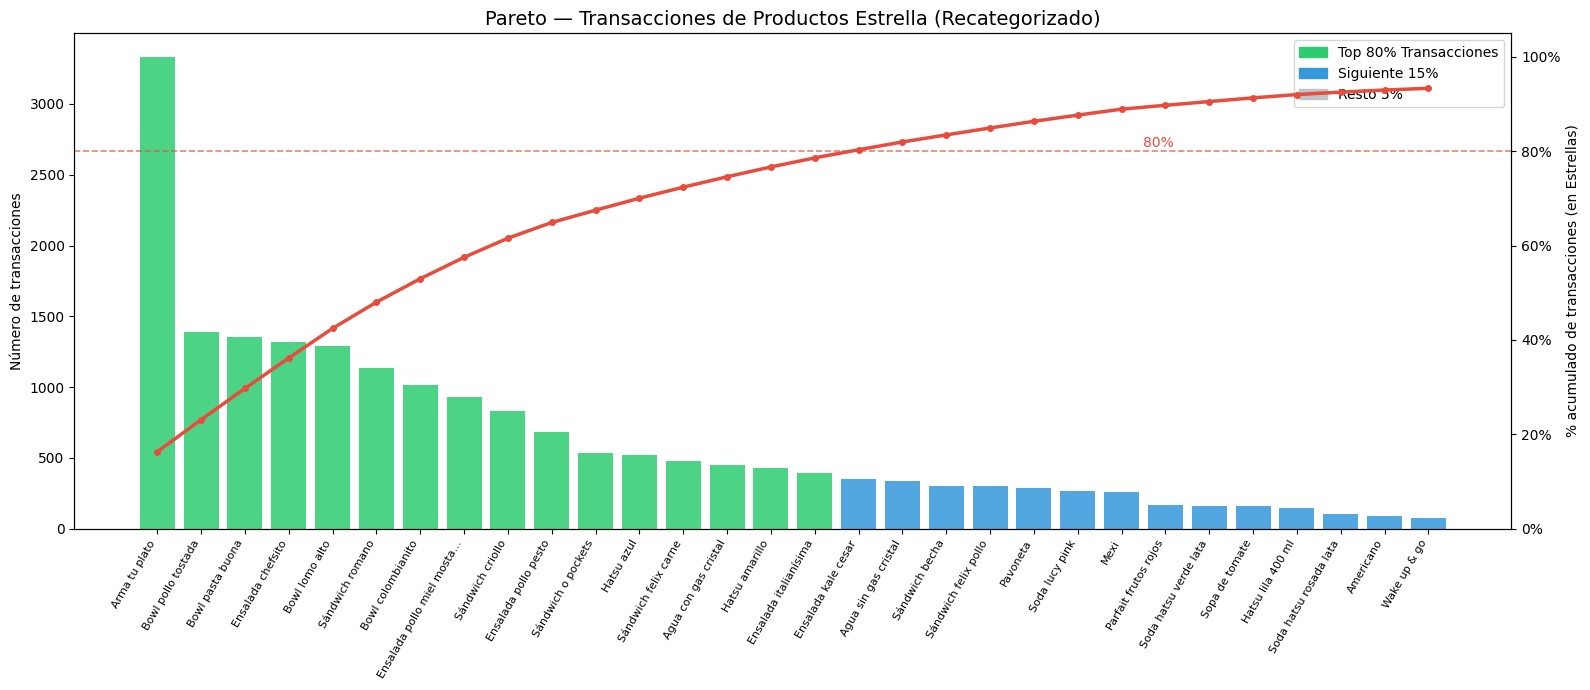

In [28]:
# 1. Filtrar solo los productos Estrella
df_estrella = info_productos[info_productos["Categoria_Matriz"] == "ESTRELLA (Alto Vol / Alto $)"].copy()

# 2. Ordenar por transacciones de mayor a menor
df_estrella = df_estrella.sort_values('transacciones', ascending=False).reset_index(drop=True)

# 3. Recalcular porcentajes sobre este nuevo total
total_trans_estrella = df_estrella['transacciones'].sum()
df_estrella['pct_trans']      = df_estrella['transacciones'] / total_trans_estrella
df_estrella['pct_trans_acum'] = df_estrella['pct_trans'].cumsum()

# 4. RECATEGORIZAR ABC (Solo para este grupo)
# Esto hará que los más vendidos de este grupo salgan en verde (A)
condiciones_estrella = [
    df_estrella['pct_trans_acum'] <= 0.80,
    df_estrella['pct_trans_acum'] <= 0.95,
]
df_estrella['Clase_ABC_Estrella'] = np.select(condiciones_estrella, ['A', 'B'], default='C')

# 5. Configurar visualización
n_mostrar = min(30, len(df_estrella))
df_plot = df_estrella.head(n_mostrar).copy()
colores = df_plot['Clase_ABC_Estrella'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})

# ── GRAFICAR ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.bar(range(n_mostrar), df_plot['transacciones'], color=colores, alpha=0.85)
ax1.set_ylabel('Número de transacciones')

ax2 = ax1.twinx()
ax2.plot(range(n_mostrar), df_plot['pct_trans_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de transacciones (en Estrellas)')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]
ax1.set_xticks(range(n_mostrar))
ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)

leyenda = [
    Patch(color='#2ecc71', label='Top 80% Transacciones'), 
    Patch(color='#3498db', label='Siguiente 15%'), 
    Patch(color='#bdc3c7', label='Resto 5%')
]
ax1.legend(handles=leyenda, loc='upper right')

plt.title('Pareto — Transacciones de Productos Estrella (Recategorizado)', fontsize=14)
plt.tight_layout()
plt.show()


In [29]:
# 1. Filtrar los productos que son Clase A en transacciones dentro de Estrellas
productos_a_trans = df_estrella[df_estrella['Clase_ABC_Estrella'] == 'A'].copy()

print(f" REPORTE: TOP TRANSACCIONES (CLASE A - ESTRELLAS)")
print(f"Estos {len(productos_a_trans)} productos mueven el 80% del volumen de tus platos estrella.")
print("=" * 95)

# 2. Seleccionar columnas relevantes para este análisis de volumen
columnas_volumen = ['Nombre', 'transacciones', 'pct_trans', 'pct_trans_acum']

# 3. Imprimir con formato limpio
print(productos_a_trans[columnas_volumen].to_string(
    index=False,
    formatters={
        'transacciones': lambda x: f"{x:,.0f}",
        'pct_trans': lambda x: f"{x*100:.1f}%",
        'pct_trans_acum': lambda x: f"{x*100:.1f}%"
    }
))

print("=" * 95)
print(f" TOTAL TRANSACCIONES CLASE A: {productos_a_trans['transacciones'].sum():,.0f}")


 REPORTE: TOP TRANSACCIONES (CLASE A - ESTRELLAS)
Estos 16 productos mueven el 80% del volumen de tus platos estrella.
                     Nombre transacciones pct_trans pct_trans_acum
              Arma tu plato         3,332     16.3%          16.3%
         Bowl pollo tostada         1,387      6.8%          23.1%
           Bowl pasta buona         1,357      6.6%          29.7%
          Ensalada chefsito         1,315      6.4%          36.2%
             Bowl lomo alto         1,287      6.3%          42.5%
            Sándwich romano         1,136      5.6%          48.0%
          Bowl colombianito         1,015      5.0%          53.0%
Ensalada pollo miel mostaza           928      4.5%          57.5%
           Sándwich criollo           828      4.1%          61.6%
       Ensalada pollo pesto           681      3.3%          64.9%
         Sándwich o pockets           532      2.6%          67.5%
                 Hatsu azul           520      2.5%          70.1%
       Sán

## 2.3 Análisis ABC — Pareto por transacciones (productos Estrella)

Segundo Pareto, ahora ordenando por **número de transacciones** (frecuencia de compra). Esto complementa el análisis de ingresos: un producto puede generar menos plata pero ser comprado con mucha más frecuencia, lo que lo hace igual de crítico para la operación.


In [30]:
# 1. Extraer nombres de los Clase A de Ventas y de Transacciones (del segmento Estrella)
set_plata = set(info_productos[info_productos['Clase_ABC'] == 'A']['Nombre'])
set_trans = set(df_estrella[df_estrella['Clase_ABC_Estrella'] == 'A']['Nombre'])

# 2. Encontrar los que están en AMBOS (Intersección)
productos_criticos = list(set_plata.intersection(set_trans))

# 3. Crear el DataFrame final de productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)].copy()

print(f"Se identificaron {len(productos_criticos)} productos críticos.")


Se identificaron 10 productos críticos.


## 2.4 Productos críticos — Intersección Clase A (plata) ∩ Clase A (transacciones)

Se identifican los productos que son **Clase A en ambos criterios**: los que más ingresos generan Y los que más frecuentemente se venden. Estos son los **productos críticos** sobre los que se construirán los modelos de pronóstico.

La intersección garantiza que pronosticamos productos que son vitales tanto en volumen como en ingresos.


In [31]:
# 1. Filtramos el DataFrame original para obtener solo los datos de los productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)]

# 2. Ordenamos para que los más importantes salgan primero en la lista
df_criticos = df_criticos.sort_values('Plata generada', ascending=False)

print(f"Hay {len(productos_criticos)} productos que son Clase A en ambos criterios:\n")

for index, row in df_criticos.iterrows():
    nombre = row['Nombre']
    trans = row['transacciones']
    ventas = row['Plata generada']
    
    # Imprimimos con formato de miles y moneda para que sea profesional
    print(f" - {nombre[:30]:<30} | Transacciones: {int(trans):>4} | Ventas: ${ventas:,.0f}")


Hay 10 productos que son Clase A en ambos criterios:

 - Arma tu plato                  | Transacciones: 3332 | Ventas: $107,097,501
 - Bowl pollo tostada             | Transacciones: 1387 | Ventas: $38,669,700
 - Ensalada chefsito              | Transacciones: 1315 | Ventas: $37,435,500
 - Bowl pasta buona               | Transacciones: 1357 | Ventas: $35,651,850
 - Bowl lomo alto                 | Transacciones: 1287 | Ventas: $34,361,900
 - Sándwich romano                | Transacciones: 1136 | Ventas: $28,473,750
 - Bowl colombianito              | Transacciones: 1015 | Ventas: $26,451,300
 - Ensalada pollo miel mostaza    | Transacciones:  928 | Ventas: $23,568,450
 - Sándwich criollo               | Transacciones:  828 | Ventas: $20,143,600
 - Ensalada pollo pesto           | Transacciones:  681 | Ventas: $16,959,000


# 3. Preparar datos para el pronóstico

Una vez identificados los **productos críticos** (Clase A en ventas y en transacciones dentro del segmento Estrella), se prepara la serie de tiempo que alimentará los modelos de pronóstico.

Los pasos son:
1. Filtrar `dataset_p` para quedarse solo con los productos críticos → `ventas_criticas`
2. Definir el **calendario académico** de la Universidad de los Andes (vacaciones, recesos, exámenes) para que Prophet lo use como regresor externo
3. Definir las funciones de preparación de serie semanal y entrenamiento de Prophet


In [32]:
# Filtrar solo las filas de los productos críticos identificados
ventas_criticas = dataset_p[dataset_p["Nombre"].isin(productos_criticos)].reset_index()

# Eliminar columna 'index' que queda del reset_index anterior
ventas_criticas.drop(columns=["index"], inplace=True)

ventas_criticas.head()


,Fecha,Nombre,Cantidad,Total
0,2024-08-05,Bowl colombianito,1.0,20700.0
1,2024-08-05,Bowl pollo tostada,1.0,20000.0
2,2024-08-05,Bowl colombianito,1.0,20000.0
3,2024-08-05,Bowl pollo tostada,1.0,20000.0
4,2024-08-05,Bowl colombianito,1.0,23000.0


### Calendario académico — DataFrame de vacaciones para Prophet

Prophet acepta un DataFrame `holidays` con columnas `holiday`, `ds`, `lower_window` y `upper_window` que le indica qué días tienen comportamiento atípico.

Se codifican los siguientes eventos para 2024, 2025 y 2026:
| Tipo | Efecto esperado en ventas |
|---|---|
| `vacaciones_verano` / `vacaciones_invierno` | **↓ fuerte**: campus casi vacío |
| `semana_receso_verano` / `semana_receso_invierno` | **↓ moderado**: muchos estudiantes viajan |
| `semana_santa` | **↓ moderado**: festivos nacionales |
| `examenes_finales` | **↓ leve**: estudiantes comen menos fuera |


In [33]:
vacaciones = pd.concat([

    # ════════════════════════════════════════════════════════════════
    # 2024
    # ════════════════════════════════════════════════════════════════

    # Semana Santa 2024 (fecha estándar colombiana)
    pd.DataFrame({
        'holiday': 'semana_santa',
        'ds': pd.date_range('2024-03-24', '2024-03-30', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana de receso 2024-I
    pd.DataFrame({
        'holiday': 'semana_receso_verano',
        'ds': pd.date_range('2024-03-18', '2024-03-23', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2024-I
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2024-05-27', '2024-06-01', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones verano 2024: fin exámenes 2024-I → inicio 2024-II
    # Jun 02 → Ago 04 (Ago 05 es el primer día de clases)
    pd.DataFrame({
        'holiday': 'vacaciones_verano',
        'ds': pd.date_range('2024-06-02', '2024-08-04', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana de receso 2024-II
    pd.DataFrame({
        'holiday': 'semana_receso_invierno',
        'ds': pd.date_range('2024-09-30', '2024-10-05', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2024-II
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2024-12-02', '2024-12-07', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones invierno 2024→2025: fin exámenes 2024-II → inicio 2025-I
    # Dic 08 → Ene 20 (Ene 21 es el primer día de clases 2025-I)
    pd.DataFrame({
        'holiday': 'vacaciones_invierno',
        'ds': pd.date_range('2024-12-08', '2025-01-20', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # ════════════════════════════════════════════════════════════════
    # 2025
    # ════════════════════════════════════════════════════════════════

    # Semana de receso 2025-I
    pd.DataFrame({
        'holiday': 'semana_receso_verano',
        'ds': pd.date_range('2025-03-17', '2025-03-22', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana Santa 2025
    pd.DataFrame({
        'holiday': 'semana_santa',
        'ds': pd.date_range('2025-04-13', '2025-04-19', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2025-I
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2025-05-26', '2025-05-31', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones verano 2025: fin exámenes 2025-I → inicio 2025-II
    # Jun 01 → Ago 03 (Ago 04 es el primer día de clases 2025-II)
    pd.DataFrame({
        'holiday': 'vacaciones_verano',
        'ds': pd.date_range('2025-06-01', '2025-08-03', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana de receso 2025-II
    pd.DataFrame({
        'holiday': 'semana_receso_invierno',
        'ds': pd.date_range('2025-09-29', '2025-10-04', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2025-II
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2025-12-01', '2025-12-06', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones invierno 2025→2026: fin exámenes 2025-II → inicio 2026-I
    # Dic 07 → Ene 19 (Ene 20 es el primer día de clases 2026-I)
    pd.DataFrame({
        'holiday': 'vacaciones_invierno',
        'ds': pd.date_range('2025-12-07', '2026-01-19', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # ════════════════════════════════════════════════════════════════
    # 2026
    # ════════════════════════════════════════════════════════════════

    # Semana de receso 2026-I
    pd.DataFrame({
        'holiday': 'semana_receso_verano',
        'ds': pd.date_range('2026-03-16', '2026-03-21', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana Santa 2026
    pd.DataFrame({
        'holiday': 'semana_santa',
        'ds': pd.date_range('2026-03-29', '2026-04-04', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2026-I
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2026-05-25', '2026-05-30', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones verano 2026: fin exámenes 2026-I → inicio 2026-II
    # May 31 → Ago 02 (Ago 03 es el primer día de clases 2026-II)
    pd.DataFrame({
        'holiday': 'vacaciones_verano',
        'ds': pd.date_range('2026-05-31', '2026-08-02', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana de receso 2026-II
    pd.DataFrame({
        'holiday': 'semana_receso_invierno',
        'ds': pd.date_range('2026-09-28', '2026-10-03', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2026-II
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2026-11-30', '2026-12-05', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones invierno 2026→2027: fin exámenes 2026-II → inicio 2027-I
    # Dic 06 → Ene 18 (siguiendo el patrón ~6 semanas)
    pd.DataFrame({
        'holiday': 'vacaciones_invierno',
        'ds': pd.date_range('2026-12-06', '2027-01-18', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

]).reset_index(drop=True)

# Verificación
print(vacaciones.groupby('holiday')['ds'].agg(['min', 'max', 'count']))


                              min        max  count
holiday                                            
examenes_finales       2024-05-27 2026-12-05     36
semana_receso_invierno 2024-09-30 2026-10-03     18
semana_receso_verano   2024-03-18 2026-03-21     18
semana_santa           2024-03-24 2026-04-04     21
vacaciones_invierno    2024-12-08 2027-01-18    132
vacaciones_verano      2024-06-02 2026-08-02    192


### Funciones auxiliares: preparar serie y entrenar Prophet

Se definen dos funciones reutilizables:

**`preparar_serie_semanal(df, nombre_producto)`**
- Filtra las ventas del producto dado
- Agrupa por semana (lunes como inicio de semana)
- Rellena semanas sin ventas con `0` para tener una serie continua
- Retorna un DataFrame con columnas `ds` (fecha) e `y` (unidades vendidas)

**`entrenar_prophet(serie)`**
- Crea un modelo Prophet con estacionalidad anual + multiplicativa
- Incluye el calendario académico y los festivos colombianos (`add_country_holidays`)
- Genera predicciones para 30 semanas hacia adelante
- Recorta predicciones negativas a 0 (ventas no pueden ser negativas)


In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import warnings
warnings.filterwarnings('ignore')

def preparar_serie_semanal(df, nombre_producto):
    df = df.copy()
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    
    # 1. Crear el "Calendario Maestro" de la tienda (Lunes a Lunes)
    f_min, f_max = df['Fecha'].min(), df['Fecha'].max()
    lunes_inicio = f_min - pd.Timedelta(days=f_min.weekday())
    lunes_fin    = f_max - pd.Timedelta(days=f_max.weekday())
    rango_maestro = pd.date_range(lunes_inicio, lunes_fin, freq='W-MON')

    # 2. Agrupar TODO el dataframe por lunes primero
    # Esto asegura que todas las fechas válidas del restaurante existan
    df['ds'] = df['Fecha'].dt.floor('D') - df['Fecha'].dt.weekday.map(lambda x: pd.Timedelta(days=x))
    
    # 3. Filtrar el producto DESPUÉS de haber normalizado las fechas
    df_prod = df[df['Nombre'] == nombre_producto]
    
    # 4. Agrupar ventas del producto por esos lunes
    serie_producto = df_prod.groupby('ds')['Cantidad'].sum().reset_index()
    
    # 5. Cruzar con el rango maestro (Aquí es donde evitamos los ceros falsos)
    # Usamos un merge 'right' para que mande el calendario de lunes
    serie_final = pd.merge(
        serie_producto, 
        pd.DataFrame({'ds': rango_maestro}), 
        on='ds', 
        how='right'
    ).fillna(0) # Solo será 0 si de verdad ese producto no se vendió esa semana
    
    serie_final = serie_final.rename(columns={'Cantidad': 'y'}).sort_values('ds')
    
    return serie_final[['ds', 'y']]

def entrenar_prophet(serie):
    modelo = Prophet(
        yearly_seasonality=False,        # insuficiente historia para anual confiable
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        holidays=vacaciones,
        changepoint_prior_scale=0.5,
        holidays_prior_scale=20.0
    )
    
    # Estacionalidad semestral: ciclo natural de Uniandes (26 semanas)
    modelo.add_seasonality(
        name='semestral',
        period=26,
        fourier_order=5
    )
    
    modelo.add_country_holidays(country_name='CO')
    modelo.fit(serie)
    
    # freq='W' para que periods=16 sean semanas, no días
    futuro = modelo.make_future_dataframe(periods=16, freq='W')
    forecast = modelo.predict(futuro)
    
    # Corrección multiplicativa en semanas de holiday
    # en lugar de penalización flat
    semanas_holiday = vacaciones['ds'].dt.to_period('W')
    forecast['es_holiday'] = forecast['ds'].dt.to_period('W').isin(semanas_holiday)
    
    forecast.loc[forecast['es_holiday'], 'yhat'] = (
        forecast.loc[forecast['es_holiday'], 'yhat'] * 0.2
    )
    
    forecast['yhat']       = np.ceil(forecast['yhat'].clip(lower=0)).astype(int)
    forecast['yhat_lower'] = np.ceil(forecast['yhat_lower'].clip(lower=0)).astype(int)
    forecast['yhat_upper'] = np.ceil(forecast['yhat_upper'].clip(lower=0)).astype(int)
    
    return modelo, forecast


## 4. Modelado con Prophet — "Arma tu plato Grande "

Se usa el producto **"Arma tu plato Grande"** como caso de prueba inicial para validar el pipeline antes de aplicarlo a todos los productos críticos.

> **Nota histórica:** Entre octubre y diciembre 2024 el local estuvo cerrado por remodelación. Ese período se trata como anomalía y se excluye de la serie antes de entrenar.


### Preparar la serie semanal del producto de prueba

Se llama a `preparar_serie_semanal` para obtener las ventas semanales del producto. Se imprime cuántas semanas totales hay y cuántas tienen ventas reales (> 0) para verificar la densidad de datos.


In [151]:
serie_completa = preparar_serie_semanal(ventas_criticas, 'Arma tu plato')
print(f"Semanas totales: {len(serie_completa)}")
print(f"Semanas con ventas: {(serie_completa['y'] > 0).sum()}")
# Ordenar por la columna de fecha (ds) de forma descendente y mostrar 10
serie_completa.sort_values('ds', ascending=False).head(10)


Semanas totales: 86
Semanas con ventas: 63


,ds,y
85,2026-03-23,86.0
84,2026-03-16,5.0
83,2026-03-09,118.0
82,2026-03-02,62.0
81,2026-02-23,112.0
80,2026-02-16,114.0
79,2026-02-09,146.0
78,2026-02-02,117.0
77,2026-01-26,170.0
76,2026-01-19,134.0


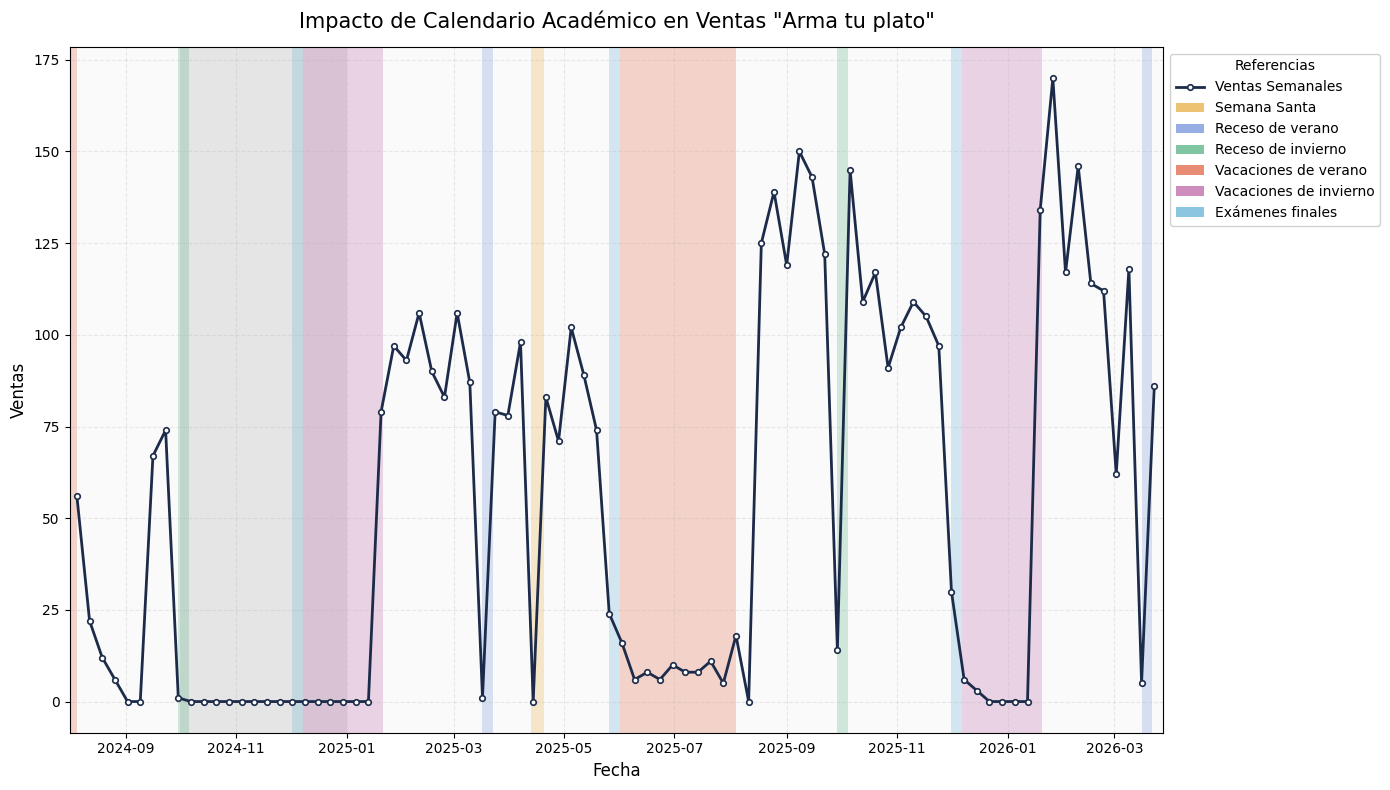

In [152]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Paleta más diferenciada por tipo ──────────────────────────────
HOLIDAY_COLORS = {
    'semana_santa':           '#E8A838',
    'semana_receso_verano':   '#6B8CDA',
    'semana_receso_invierno': '#4BAF7D',
    'vacaciones_verano':      '#E05C3A',
    'vacaciones_invierno':    '#B85BA0',
    'examenes_finales':       '#5AAED4',
}

HOLIDAY_LABELS = {
    'semana_santa':           'Semana Santa',
    'semana_receso_verano':   'Receso de verano',
    'semana_receso_invierno': 'Receso de invierno',
    'vacaciones_verano':      'Vacaciones de verano',
    'vacaciones_invierno':    'Vacaciones de invierno',
    'examenes_finales':       'Exámenes finales',
}

# ── Gráfico ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

# 1. Serie de tiempo con marker en cada punto semanal
ax.plot(
    serie_completa['ds'], serie_completa['y'],
    color='#1C2B4A',
    linewidth=2,
    marker='o',          # círculo en cada semana
    markersize=4,
    markerfacecolor='white',
    markeredgecolor='#1C2B4A',
    markeredgewidth=1.2,
    zorder=4
)

# 2. Sombrear periodos
for holiday, grupo in vacaciones.groupby('holiday'):
    color = HOLIDAY_COLORS.get(holiday, '#AAAAAA')

    fechas = grupo['ds'].sort_values()
    inicio = None
    fin_anterior = None

    for fecha in fechas:
        if inicio is None:
            inicio = fecha
            fin_anterior = fecha
        elif (fecha - fin_anterior).days <= 1:
            fin_anterior = fecha
        else:
            ax.axvspan(inicio, fin_anterior + pd.Timedelta(days=1),
                       color=color, alpha=0.25, linewidth=0, zorder=1)
            inicio = fecha
            fin_anterior = fecha

    if inicio is not None:
        ax.axvspan(inicio, fin_anterior + pd.Timedelta(days=1),
                   color=color, alpha=0.25, linewidth=0, zorder=1)

# 3. Leyenda
serie_handle = plt.Line2D(
    [0], [0],
    color='#1C2B4A', linewidth=2,
    marker='o', markersize=4,
    markerfacecolor='white', markeredgecolor='#1C2B4A', markeredgewidth=1.2,
    label='Ventas Semanales'
)

holiday_handles = [
    mpatches.Patch(
        facecolor=HOLIDAY_COLORS[h],
        alpha=0.7,
        label=HOLIDAY_LABELS[h]
    )
    for h in HOLIDAY_COLORS
    if h in vacaciones['holiday'].values
]

ax.legend(
    handles=[serie_handle] + holiday_handles,
    loc='upper left',
    bbox_to_anchor=(1, 1),
    framealpha=0.9,
    edgecolor='#CCCCCC',
    title='Referencias',
    title_fontsize=10
)

# 4. Personalización
ax.set_title(
    'Impacto de Calendario Académico en Ventas "Arma tu plato"',
    fontsize=15, pad=14
)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Ventas', fontsize=12)
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
ax.set_xlim(pd.Timestamp('2024-08-01'), pd.Timestamp('2026-03-28'))
plt.show()


### Entrenar Prophet y ver el pronóstico inicial

Se entrena el modelo con la función `entrenar_prophet` y se muestran las últimas 4 semanas pronosticadas (`yhat`, `yhat_lower`, `yhat_upper`). Este es un modelo base para ver si el pipeline funciona antes de limpiar el período de cierre.


In [153]:
modelo_base, forecast_base = entrenar_prophet(serie_completa)
forecast_base[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(4)


19:05:24 - cmdstanpy - INFO - Chain [1] start processing
19:05:26 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
98,2026-06-21,0,0,17
99,2026-06-28,0,0,26
100,2026-07-05,4,0,48
101,2026-07-12,0,0,20


### Manejar el período de cierre (oct–dic 2024)

El local estuvo **cerrado por remodelación** entre octubre y diciembre de 2024. Ese período genera ceros atípicos que confunden al modelo haciéndolo pensar que en Q4 siempre hay cero ventas.

**Solución:** 
1. Eliminar esas semanas de la serie de entrenamiento para no distorsionar la tendencia
2. Marcar esas semanas como holidays para marcar las ventas de esas semanas como atipicas

In [154]:
# Eliminar las semanas de oct-dic 2024 (período de cierre por remodelación)
# Estas semanas tienen y=0 que no representan demanda real, sino ausencia de operación
serie_completa = serie_completa[
    ~((serie_completa['ds'].dt.year == 2024) &
      (serie_completa['ds'].dt.month.isin([10, 11, 12])))
].reset_index(drop=True)

print(f"Semanas totales : {len(serie_completa)}")
print(f"Desde           : {serie_completa['ds'].min().date()}")
print(f"Hasta           : {serie_completa['ds'].max().date()}")
print(f"\nPrimeras semanas:")
print(serie_completa.head(10).to_string())


Semanas totales : 73
Desde           : 2024-08-05
Hasta           : 2026-03-23

Primeras semanas:
          ds     y
0 2024-08-05  56.0
1 2024-08-12  22.0
2 2024-08-19  12.0
3 2024-08-26   6.0
4 2024-09-02   0.0
5 2024-09-09   0.0
6 2024-09-16  67.0
7 2024-09-23  74.0
8 2024-09-30   1.0
9 2025-01-06   0.0


In [ ]:
cierre_oct_dic_2024 = pd.DataFrame({
    'holiday': 'cierre_oct_dic_2024',
    'ds': pd.date_range('2024-10-01', '2024-12-31', freq='D'),
    'lower_window': 0,
    'upper_window': 0
})

vacaciones = pd.concat([vacaciones, cierre_oct_dic_2024]).reset_index(drop=True)

# Verificar
print(vacaciones[vacaciones['holiday'] == 'cierre_oct_dic_2024'][['ds']].agg(['min', 'max']))
print(f"Días agregados: {(vacaciones['holiday'] == 'cierre_oct_dic_2024').sum()}")


            ds
min 2024-10-01
max 2024-12-31
Días agregados: 644


### Entrenar Prophet sin el período de cierre + visualización del pronóstico

Se entrena un modelo limpio con la serie sin oct–dic 2024 y se genera el pronóstico para 26 semanas (~6 meses). El gráfico muestra:
- **Línea azul punteada**: ajuste del modelo en el histórico
- **Línea naranja**: pronóstico futuro
- **Puntos negros**: ventas reales
- **Banda naranja**: intervalo de confianza del pronóstico


In [156]:
modelo, forecast = entrenar_prophet(serie_completa)


19:05:43 - cmdstanpy - INFO - Chain [1] start processing
19:05:43 - cmdstanpy - INFO - Chain [1] done processing


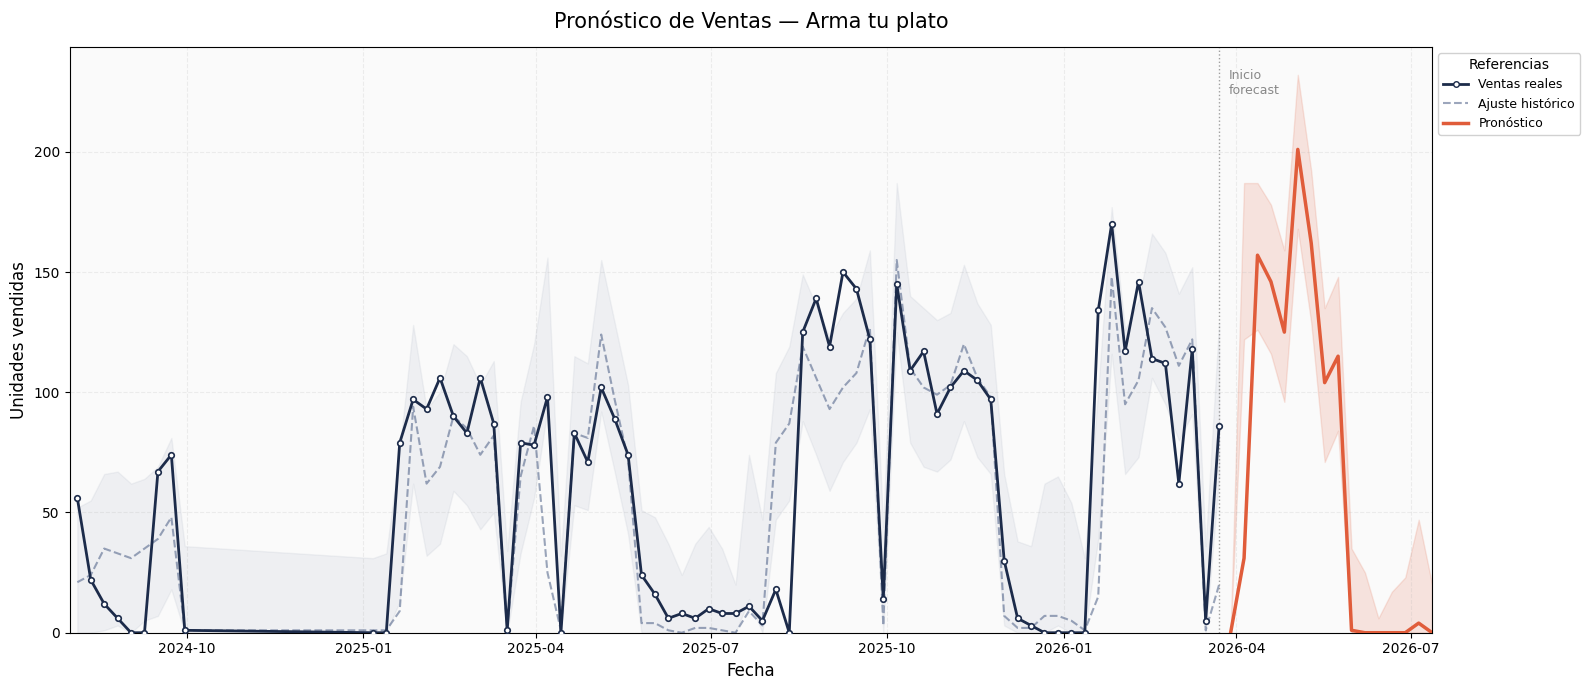

In [158]:
# Clampear yhat y bandas a 0 (ventas no pueden ser negativas)
forecast['yhat']       = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

fig, ax = plt.subplots(figsize=(16, 7))

ultimo_dato = serie_completa['ds'].max()
hist = forecast[forecast['ds'] <= ultimo_dato]
fut  = forecast[forecast['ds'] >  ultimo_dato]

# Banda de incertidumbre — más sutil en histórico
ax.fill_between(hist['ds'], hist['yhat_lower'], hist['yhat_upper'],
                color='#3A4F7A', alpha=0.06, zorder=1)
ax.fill_between(fut['ds'], fut['yhat_lower'], fut['yhat_upper'],
                color='#E05C3A', alpha=0.15, zorder=1)

# Líneas de predicción
ax.plot(hist['ds'], hist['yhat'],
        color='#3A4F7A', linewidth=1.5, linestyle='--',
        alpha=0.5, zorder=2, label='Ajuste histórico')
ax.plot(fut['ds'], fut['yhat'],
        color='#E05C3A', linewidth=2.5,
        zorder=3, label='Pronóstico')

# Datos reales
ax.plot(serie_completa['ds'], serie_completa['y'],
        color='#1C2B4A', linewidth=2,
        marker='o', markersize=4,
        markerfacecolor='white', markeredgecolor='#1C2B4A',
        markeredgewidth=1.2, zorder=4, label='Ventas reales')

# Línea vertical de corte
ax.axvline(ultimo_dato, color='#888888', linewidth=1,
           linestyle=':', alpha=0.8)
ax.text(ultimo_dato + pd.Timedelta(days=5),
        ax.get_ylim()[1] * 0.92,
        'Inicio\nforecast', fontsize=9, color='#888888')

# Forzar eje Y a no bajar de 0
ax.set_ylim(bottom=0)

# ── Leyenda ────────────────────────────────────────────────────────
serie_handles = [
    Line2D([0],[0], color='#1C2B4A', linewidth=2, marker='o',
           markersize=4, markerfacecolor='white',
           markeredgecolor='#1C2B4A', label='Ventas reales'),
    Line2D([0],[0], color='#3A4F7A', linewidth=1.5,
           linestyle='--', alpha=0.5, label='Ajuste histórico'),
    Line2D([0],[0], color='#E05C3A', linewidth=2.5, label='Pronóstico'),
]

ax.legend(
    handles=serie_handles,
    loc='upper left', bbox_to_anchor=(1, 1),
    framealpha=0.9, edgecolor='#CCCCCC',
    title='Referencias', title_fontsize=10,
    fontsize=9
)

ax.set_title('Pronóstico de Ventas — Arma tu plato',
             fontsize=15, pad=14)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Unidades vendidas', fontsize=12)
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')
ax.set_xlim(pd.Timestamp('2024-08-01'), fut['ds'].max())

plt.tight_layout()
plt.show()


### Validación cruzada (Cross-Validation) de Prophet

Se usa `cross_validation` de Prophet para evaluar qué tan bien generaliza el modelo. El parámetro `initial` define cuántos datos usar como entrenamiento mínimo antes del primer fold.

**Problema:** Con `initial=385 días`, el primer fold incluye el gap de cierre (oct–dic 2024), lo que produce predicciones desbocadas (yhat > 500). Se necesita aumentar `initial` para que el primer cutoff sea después del período de cierre.

**Métricas a interpretar:**
- **SMAPE**: error porcentual simétrico (más robusto que MAPE con ceros)
- **RMSE**: error en unidades, penaliza errores grandes
- **MAE**: error promedio absoluto en unidades


In [159]:
# Con 68 semanas totales el initial debe ser menor
# para tener suficientes folds, pero mayor a 365 días

# Opción: usar 55 semanas de initial (~385 días)
initial_days = 55 * 7  # 385 días > 365.25

print(f"Initial: {initial_days} días ({initial_days//7} semanas)")
print(f"Semanas restantes para CV: {68 - initial_days//7}")

cv_results = cross_validation(
    modelo,
    initial=f'{initial_days} days',
    period='7 days',   # fold cada semana para aprovechar más
    horizon='28 days',
    parallel='processes'
)

metricas = performance_metrics(cv_results, rolling_window=1)
print(metricas[['horizon', 'smape', 'rmse', 'mae']].to_string(index=False))
print(f"\nFolds generados: {cv_results['cutoff'].nunique()}")


Initial: 385 días (55 semanas)
Semanas restantes para CV: 13
horizon    smape     rmse       mae
28 days 0.752918 51.49289 40.808114

Folds generados: 27


In [ ]:
print("=== SERIE COMPLETA ===")
print(serie_completa[['ds', 'y']].describe())
print(f"\nMáximo: {serie_completa['y'].max()}")
print(f"Mínimo: {serie_completa['y'].min()}")
print(f"Promedio: {serie_completa['y'].mean():.2f}")

print("\n=== CV RESULTS ===")
print(cv_results[['ds', 'yhat', 'y']].head(20).to_string())


=== SERIE COMPLETA ===
                                  ds           y
count                             73   73.000000
mean   2025-07-02 18:44:23.013698560   62.520548
min              2024-08-05 00:00:00    0.000000
25%              2025-03-10 00:00:00    6.000000
50%              2025-07-14 00:00:00   74.000000
75%              2025-11-17 00:00:00  106.000000
max              2026-03-23 00:00:00  170.000000
std                              NaN   52.087562

Máximo: 170.0
Mínimo: 0.0
Promedio: 62.52

=== CV RESULTS ===
           ds        yhat      y
0  2025-09-01   83.743194  119.0
1  2025-09-08   64.396312  150.0
2  2025-09-15  116.864609  143.0
3  2025-09-22  112.557432  122.0
4  2025-09-08   72.650568  150.0
5  2025-09-15  144.082398  143.0
6  2025-09-22  132.796626  122.0
7  2025-09-29    2.368386   14.0
8  2025-09-15  193.134688  143.0
9  2025-09-22  153.132568  122.0
10 2025-09-29    3.089187   14.0
11 2025-10-06  151.213102  145.0
12 2025-09-22  142.892550  122.0
13 2025-09-

### Calibrar el `initial` de Cross-Validation

Se prueban distintos valores de `initial` (420, 460 días) para evitar que los folds caigan en el período de cierre. El objetivo es que el **primer cutoff sea ≥ noviembre 2025** (cuando el local ya tiene datos estables post-reapertura).


In [161]:
# Analizar dónde falla el modelo
cv_results['error_abs'] = abs(cv_results['y'] - cv_results['yhat'])
cv_results['es_cero']   = cv_results['y'] == 0

print("Error cuando y = 0:")
print(cv_results[cv_results['es_cero']][['y', 'yhat', 'error_abs']].describe())

print("\nError cuando y > 0:")
print(cv_results[~cv_results['es_cero']][['y', 'yhat', 'error_abs']].describe())

# SMAPE solo en semanas con ventas reales
cv_activo = cv_results[cv_results['y'] > 0].copy()
smape_activo = (
    2 * abs(cv_activo['y'] - cv_activo['yhat']) /
    (abs(cv_activo['y']) + abs(cv_activo['yhat']))
).mean()

print(f"\nSMAPE excluyendo semanas en cero : {smape_activo:.3f}")
print(f"SMAPE incluyendo semanas en cero  : {metricas['smape'].mean():.3f}")


Error cuando y = 0:
          y        yhat   error_abs
count  16.0   16.000000   16.000000
mean    0.0   47.723412   52.480204
std     0.0   42.741269   36.309665
min     0.0  -15.816793    7.716584
25%     0.0    8.708139   15.458711
50%     0.0   54.756585   54.756585
75%     0.0   89.617903   89.617903
max     0.0  102.049783  102.049783

Error cuando y > 0:
                y        yhat   error_abs
count   92.000000   92.000000   92.000000
mean    96.934783  106.356135   38.778185
std     47.430876   47.591217   30.414085
min      3.000000    1.717533    1.021539
25%     89.750000   76.474421   12.101262
50%    109.000000  106.197914   30.435060
75%    122.000000  139.704053   57.306462
max    170.000000  208.214334  116.871075

SMAPE excluyendo semanas en cero : 0.536
SMAPE incluyendo semanas en cero  : 0.753


In [162]:
# Encontrar las predicciones desbocadas
problemas = cv_results[cv_results['yhat'] > 500].sort_values('yhat', ascending=False)
print("Predicciones anómalas (yhat > 500):")
print(problemas[['ds', 'cutoff', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].to_string())

# Ver en qué cutoffs ocurre
print("\nCutoffs problemáticos:")
print(problemas['cutoff'].unique())

# Distribución general de yhat
print("\nDistribución de yhat:")
print(cv_results['yhat'].describe())


Predicciones anómalas (yhat > 500):
Empty DataFrame
Columns: [ds, cutoff, y, yhat, yhat_lower, yhat_upper]
Index: []

Cutoffs problemáticos:
<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]

Distribución de yhat:
count    108.000000
mean      97.669806
std       51.188329
min      -15.816793
25%       72.627561
50%       95.349899
75%      135.117481
max      208.214334
Name: yhat, dtype: float64


In [163]:
# El gap termina en dic 2024, entonces el initial
# debe cubrir hasta al menos oct 2025 para tener
# un octubre real en el entrenamiento

# Fecha de inicio de la serie: ago 2024
# Fecha que queremos como mínimo cutoff: oct 2025
# Diferencia: ~14 meses = ~420 días

initial_days = 420  # cubre hasta oct 2025 como primer cutoff

print(f"Initial: {initial_days} días ({initial_days//7} semanas)")
print(f"Primer cutoff aproximado: {(serie_completa['ds'].min() + pd.Timedelta(days=initial_days)).date()}")

cv_results2 = cross_validation(
    modelo,
    initial=f'{initial_days} days',
    period='7 days',
    horizon='28 days',
    parallel='processes'
)

# Verificar que no hay predicciones desbocadas
print(f"\nyhat max: {cv_results2['yhat'].max():.1f}")
print(f"Folds  : {cv_results2['cutoff'].nunique()}")

metricas2 = performance_metrics(cv_results2, rolling_window=1)
print(metricas2[['horizon', 'smape', 'rmse', 'mae']].to_string(index=False))


Initial: 420 días (60 semanas)
Primer cutoff aproximado: 2025-09-29

yhat max: 208.2
Folds  : 22
horizon    smape    rmse       mae
28 days 0.819206 54.6727 44.272473


In [164]:
# Forzar que el primer cutoff sea después de oct 2025
# Serie empieza ago 2024, oct 2025 está a ~440 días
# Necesitamos initial > 440 días

initial_days = 460  # primer cutoff ~nov 2025

print(f"Initial: {initial_days} días ({initial_days//7} semanas)")
print(f"Primer cutoff: {(serie_completa['ds'].min() + pd.Timedelta(days=initial_days)).date()}")

cv_results3 = cross_validation(
    modelo,
    initial=f'{initial_days} days',
    period='7 days',
    horizon='28 days',
    parallel='processes'
)

print(f"\nyhat max  : {cv_results3['yhat'].max():.1f}")
print(f"yhat min  : {cv_results3['yhat'].min():.1f}")
print(f"Folds     : {cv_results3['cutoff'].nunique()}")
print(f"Cutoffs   :")
for c in sorted(cv_results3['cutoff'].unique()):
    print(f"  {c.date()}")

metricas3 = performance_metrics(cv_results3, rolling_window=1)
print(metricas3[['horizon', 'smape', 'rmse', 'mae']].to_string(index=False))


Initial: 460 días (65 semanas)
Primer cutoff: 2025-11-08

yhat max  : 208.2
yhat min  : -15.8
Folds     : 16
Cutoffs   :
  2025-11-10
  2025-11-17
  2025-11-24
  2025-12-01
  2025-12-08
  2025-12-15
  2025-12-22
  2025-12-29
  2026-01-05
  2026-01-12
  2026-01-19
  2026-01-26
  2026-02-02
  2026-02-09
  2026-02-16
  2026-02-23
horizon    smape     rmse       mae
28 days 1.046929 62.60631 53.464317


In [165]:
# Identificar el fold problemático restante
problemas3 = cv_results3[cv_results3['yhat'] > 200].sort_values('yhat', ascending=False)
print(problemas3[['ds', 'cutoff', 'y', 'yhat']].to_string())

# Excluir predicciones desbocadas y recalcular SMAPE limpio
cv_limpio = cv_results3[
    (cv_results3['yhat'] <= 200) &
    (cv_results3['yhat'] >= 0) &
    (cv_results3['y'] > 0)
].copy()

smape_limpio = (
    2 * abs(cv_limpio['y'] - cv_limpio['yhat']) /
    (abs(cv_limpio['y']) + abs(cv_limpio['yhat']))
).mean()

print(f"\nSMAPE sin outliers ni ceros : {smape_limpio:.3f}")
print(f"MAE  sin outliers ni ceros  : {abs(cv_limpio['y'] - cv_limpio['yhat']).mean():.1f}")
print(f"Observaciones usadas        : {len(cv_limpio)} de {len(cv_results3)}")


           ds     cutoff      y        yhat
52 2026-02-16 2026-02-09  114.0  208.214334

SMAPE sin outliers ni ceros : 0.732
MAE  sin outliers ni ceros  : 52.9
Observaciones usadas        : 47 de 64


## 5. Modelo combinado — "Arma tu plato"

En lugar de modelar cada tamaño de plato por separado (serie corta y ruidosa), se **combina la demanda** de Grande (21k) y Mediano (18k) en una sola serie. 

**Razón:** Los dos productos son sustitutos cercanos y comparten el mismo patrón de demanda. Combinarlos da una serie con más señal y menos ruido, lo que mejora significativamente la calidad del pronóstico.


In [166]:
# Aplicar la misma limpieza del período de cierre a la serie combinada
serie_combinada=serie_completa
serie_combinada = serie_combinada[
    ~((serie_combinada['ds'].dt.year == 2024) &
      (serie_combinada['ds'].dt.month.isin([10, 11, 12])))
].reset_index(drop=True)

print(f"Semanas totales : {len(serie_combinada)}")
print(f"Desde           : {serie_combinada['ds'].min().date()}")
print(f"Hasta           : {serie_combinada['ds'].max().date()}")
print(f"Semanas en cero : {(serie_combinada['y'] == 0).sum()}")

# ── Entrenar modelo Prophet sobre la serie combinada ──────────────
modelo_combinado = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,    # granularidad semanal ya está en la serie
    daily_seasonality=False,
    holidays=vacaciones          # calendario académico Uniandes
)

modelo_combinado.fit(serie_combinada)

# ── Generar pronóstico para 26 semanas (~6 meses) ─────────────────
future = modelo_combinado.make_future_dataframe(periods=26, freq='W')
forecast_combinado = modelo_combinado.predict(future)

# Clampear predicciones negativas a 0 (ventas no pueden ser negativas)
forecast_combinado['yhat']       = forecast_combinado['yhat'].clip(lower=0)
forecast_combinado['yhat_lower'] = forecast_combinado['yhat_lower'].clip(lower=0)
forecast_combinado['yhat_upper'] = forecast_combinado['yhat_upper'].clip(lower=0)

print(forecast_combinado[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10).to_string())


Semanas totales : 73
Desde           : 2024-08-05
Hasta           : 2026-03-23
Semanas en cero : 10


19:07:20 - cmdstanpy - INFO - Chain [1] start processing
19:07:20 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper
89 2026-07-19   48.176369   18.798348   78.802249
90 2026-07-26   51.770419   21.605929   81.938320
91 2026-08-02   58.963640   28.091540   88.811268
92 2026-08-09   92.626192   64.618406  121.561136
93 2026-08-16  109.725388   80.468528  139.608457
94 2026-08-23  125.750301   94.383568  155.397639
95 2026-08-30  134.419932  104.080922  163.735690
96 2026-09-06  137.095342  107.593774  167.827506
97 2026-09-13  143.186678  113.299947  172.622537
98 2026-09-20  159.246864  127.789698  190.688438


### Limpiar serie combinada y entrenar Prophet

Se aplica la misma limpieza del período de cierre (oct–dic 2024) a la serie combinada, y se entrena un nuevo modelo Prophet sobre la serie agregada. Se genera el pronóstico de 26 semanas.


In [167]:
from prophet.diagnostics import cross_validation, performance_metrics

initial_days = 460

print(f"Initial: {initial_days} días ({initial_days//7} semanas)")
print(f"Primer cutoff: {(serie_combinada['ds'].min() + pd.Timedelta(days=initial_days)).date()}")

cv_combinado = cross_validation(
    modelo_combinado,
    initial=f'{initial_days} days',
    period='7 days',
    horizon='28 days',
    parallel='processes'
)

# Verificar outliers
print(f"\nyhat max : {cv_combinado['yhat'].max():.1f}")
print(f"yhat min : {cv_combinado['yhat'].min():.1f}")
print(f"Folds    : {cv_combinado['cutoff'].nunique()}")

metricas_comb = performance_metrics(cv_combinado, rolling_window=1)
print(metricas_comb[['horizon', 'smape', 'rmse', 'mae']].to_string(index=False))


Initial: 460 días (65 semanas)
Primer cutoff: 2025-11-08

yhat max : 663.2
yhat min : -5.0
Folds    : 16
horizon    smape       rmse       mae
28 days 1.031904 139.659203 81.367704


### Cross-Validation del modelo combinado

Se valida el modelo combinado con los mismos parámetros (`initial=460 días`) y se analiza el SMAPE en periodos activos (excluyendo semanas de cero por vacaciones y outliers de diciembre).


In [168]:
# Filtrar solo semanas donde el local estaba activo (y > 0)
# y sin los outliers de diciembre (yhat desbocado por el gap de datos)
cv_activo = cv_combinado[
    (cv_combinado['y'] > 0) &
    (cv_combinado['yhat'] < 400)   # excluir outliers de dic causados por el gap
].copy()

# Calcular SMAPE solo en períodos activos
smape_activo = (
    2 * abs(cv_activo['y'] - cv_activo['yhat']) /
    (abs(cv_activo['y']) + abs(cv_activo['yhat']))
).mean()

mae_activo = abs(cv_activo['y'] - cv_activo['yhat']).mean()

print(f"En periodos activos (sin dic ni ceros):")
print(f"  SMAPE : {smape_activo:.3f}  ({smape_activo*100:.1f}%)")
print(f"  MAE   : {mae_activo:.1f} unidades")
print(f"  Obs   : {len(cv_activo)}")

# Contexto de negocio: ¿el error es grande o pequeño?
promedio_ventas = serie_combinada[serie_combinada['y'] > 0]['y'].mean()
print(f"\nPromedio ventas activas : {promedio_ventas:.1f} unidades/semana")
print(f"Error como % del prom   : {mae_activo/promedio_ventas*100:.1f}%")


En periodos activos (sin dic ni ceros):
  SMAPE : 0.659  (65.9%)
  MAE   : 69.5 unidades
  Obs   : 46

Promedio ventas activas : 72.4 unidades/semana
Error como % del prom   : 96.0%


### Métricas en periodos activos (semestre en curso)

El SMAPE global se distorsiona por las semanas de vacaciones (y=0). Se filtra para analizar **solo semanas donde el local estaba activo** (y > 0) y sin outliers de diciembre, que es la métrica más relevante para la operación.


In [169]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import numpy as np

# ── Feature engineering ────────────────────────────────────────────
def crear_features(serie, vacaciones):
    df = serie.copy()
    
    # Features de calendario
    df['mes']           = df['ds'].dt.month
    df['semana_año']    = df['ds'].dt.isocalendar().week.astype(int)
    df['trimestre']     = df['ds'].dt.quarter
    
    # Lags (ventas semanas anteriores)
    df['lag_1']  = df['y'].shift(1)   # semana anterior
    df['lag_2']  = df['y'].shift(2)   # 2 semanas atrás
    df['lag_4']  = df['y'].shift(4)   # 1 mes atrás
    df['lag_52'] = df['y'].shift(52)  # mismo periodo año anterior
    
    # Rolling means
    df['rolling_4']  = df['y'].shift(1).rolling(4).mean()   # promedio 1 mes
    df['rolling_8']  = df['y'].shift(1).rolling(8).mean()   # promedio 2 meses
    
    # Features de vacaciones (binarias)
    for holiday in vacaciones['holiday'].unique():
        fechas_holiday = vacaciones[vacaciones['holiday'] == holiday]['ds']
        # Marcar semanas que contienen días de ese holiday
        df[f'hol_{holiday}'] = df['ds'].apply(
            lambda x: int(any(
                (fechas_holiday >= x) & 
                (fechas_holiday < x + pd.Timedelta(days=7))
            ))
        )
    
    # Semanas antes/después de vacaciones (efecto anticipación)
    df['semanas_antes_verano'] = df['ds'].apply(
        lambda x: max(0, 4 - (
            vacaciones[vacaciones['holiday'] == 'vacaciones_verano']['ds'].min() - x
        ).days // 7) if (
            vacaciones[vacaciones['holiday'] == 'vacaciones_verano']['ds'].min() - x
        ).days > 0 else 0
    )
    
    return df

# ── Aplicar features ───────────────────────────────────────────────
df_features = crear_features(serie_combinada, vacaciones)

print("Features creadas:")
print(df_features.columns.tolist())
print(f"\nShape: {df_features.shape}")
print(df_features.tail(5).to_string())


Features creadas:
['ds', 'y', 'mes', 'semana_año', 'trimestre', 'lag_1', 'lag_2', 'lag_4', 'lag_52', 'rolling_4', 'rolling_8', 'hol_semana_santa', 'hol_semana_receso_verano', 'hol_examenes_finales', 'hol_vacaciones_verano', 'hol_semana_receso_invierno', 'hol_vacaciones_invierno', 'hol_cierre_oct_dic_2024', 'semanas_antes_verano']

Shape: (73, 19)
           ds      y  mes  semana_año  trimestre  lag_1  lag_2  lag_4  lag_52  rolling_4  rolling_8  hol_semana_santa  hol_semana_receso_verano  hol_examenes_finales  hol_vacaciones_verano  hol_semana_receso_invierno  hol_vacaciones_invierno  hol_cierre_oct_dic_2024  semanas_antes_verano
68 2026-02-23  112.0    2           9          1  114.0  146.0  170.0    83.0     136.75     85.125                 0                         0                     0                      0                           0                        0                        0                     0
69 2026-03-02   62.0    3          10          1  112.0  114.0  117.0   1

### Visualización del pronóstico XGBoost (próximas 4 semanas)

Gráfico que combina el histórico reciente (últimas 20 semanas) con las 4 semanas pronosticadas por XGBoost. La banda naranja representa el rango estimado (±30% del yhat como proxy del intervalo de confianza). Se marca también el inicio del receso de verano.


In [170]:
# ── 1. Obtener predicciones de Prophet en el histórico ────────────
forecast_hist = forecast_combinado[
    forecast_combinado['ds'].isin(serie_combinada['ds'])
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

forecast_hist['yhat']       = forecast_hist['yhat'].clip(0)
forecast_hist['yhat_lower'] = forecast_hist['yhat_lower'].clip(0)
forecast_hist['yhat_upper'] = forecast_hist['yhat_upper'].clip(0)

# ── 2. Unir con serie real ─────────────────────────────────────────
df_hibrido = serie_combinada.merge(forecast_hist, on='ds', how='left')
df_hibrido['residuo'] = df_hibrido['y'] - df_hibrido['yhat']  # lo que Prophet no capturó

print("Residuos de Prophet:")
print(df_hibrido[['ds', 'y', 'yhat', 'residuo']].tail(15).to_string(index=False))
print(f"\nResiduo promedio : {df_hibrido['residuo'].mean():.1f}")
print(f"Residuo std      : {df_hibrido['residuo'].std():.1f}")


Residuos de Prophet:
        ds     y       yhat    residuo
2025-12-15   3.0   5.272410  -2.272410
2025-12-22   0.0   0.000000   0.000000
2025-12-29   0.0   0.000000   0.000000
2026-01-05   0.0   8.529945  -8.529945
2026-01-12   0.0  49.140968 -49.140968
2026-01-19 134.0  98.557724  35.442276
2026-01-26 170.0 144.917872  25.082128
2026-02-02 117.0 150.237963 -33.237963
2026-02-09 146.0 135.867458  10.132542
2026-02-16 114.0 121.008892  -7.008892
2026-02-23 112.0 115.939235  -3.939235
2026-03-02  62.0 116.066524 -54.066524
2026-03-09 118.0 113.312651   4.687349
2026-03-16   5.0  23.893134 -18.893134
2026-03-23  86.0 109.299276 -23.299276

Residuo promedio : -1.0
Residuo std      : 23.2


## 7. Modelo Híbrido — Prophet + XGBoost

**Idea:** Prophet captura bien la tendencia y la estacionalidad (largo plazo), pero falla en patrones de corto plazo. XGBoost captura bien los patrones recientes (lags) pero no tiene estructura para el largo plazo.

**Estrategia híbrida:**
1. Prophet predice la serie → genera `yhat` (tendencia base)
2. XGBoost aprende los **residuos** de Prophet (lo que Prophet no capturó)
3. Predicción final = `yhat_prophet + yhat_residuo_xgb`

Esto combina lo mejor de ambos mundos: la estructura temporal de Prophet y la capacidad de corrección de XGBoost.


In [171]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# ── Features y target ─────────────────────────────────────────────
X_train_xgb = train_h[FEATURES_HIBRIDO]
X_test_xgb  = test_h[FEATURES_HIBRIDO]
y_train_xgb = train_h['y']   # <- aprende ventas directamente, no residuo
y_test_xgb  = test_h['y']

# ── Modelo ────────────────────────────────────────────────────────
modelo_xgb_solo = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

modelo_xgb_solo.fit(X_train_xgb, y_train_xgb, verbose=False)

# ── Predicción ────────────────────────────────────────────────────
pred_xgb_solo = modelo_xgb_solo.predict(X_test_xgb).clip(0)
mae_xgb_solo  = mean_absolute_error(y_test_xgb, pred_xgb_solo)

print(f"MAE XGBoost solo: {mae_xgb_solo:.1f}")


MAE XGBoost solo: 19.6


In [172]:
# ── 3. Crear features para el modelo de residuos ──────────────────
df_hibrido_feat = crear_features(df_hibrido[['ds', 'y']].rename(columns={'y': 'y'}), vacaciones)

# Agregar predicción de Prophet como feature
df_hibrido_feat = df_hibrido_feat.merge(
    df_hibrido[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'residuo']],
    on='ds', how='left'
)

# Features incluyendo prophet
FEATURES_HIBRIDO = [
    'yhat',           # predicción de Prophet  ← feature más importante
    'yhat_lower',     # banda inferior
    'yhat_upper',     # banda superior
    'mes', 'semana_año', 'trimestre',
    'lag_1', 'lag_2', 'lag_4',
    'rolling_4', 'rolling_8',
    'hol_semana_santa', 'hol_semana_receso_verano',
    'hol_examenes_finales', 'hol_vacaciones_verano',
    'hol_semana_receso_invierno', 'hol_vacaciones_invierno',
    'hol_cierre_oct_dic_2024', 'semanas_antes_verano'
]

df_modelo_h = df_hibrido_feat.dropna(subset=FEATURES_HIBRIDO).copy()
print(f"Filas disponibles: {len(df_modelo_h)}")

# ── 4. Split temporal 80/20 ────────────────────────────────────────
corte = int(len(df_modelo_h) * 0.80)
train_h = df_modelo_h.iloc[:corte]
test_h  = df_modelo_h.iloc[corte:]

print(f"Train: {len(train_h)} semanas → {train_h['ds'].min().date()} a {train_h['ds'].max().date()}")
print(f"Test : {len(test_h)} semanas  → {test_h['ds'].min().date()} a {test_h['ds'].max().date()}")

X_train_h = train_h[FEATURES_HIBRIDO]
X_test_h  = test_h[FEATURES_HIBRIDO]

# ── 5. XGBoost aprende el residuo ─────────────────────────────────
y_train_residuo = train_h['residuo']
y_test_real     = test_h['y']

modelo_xgb_h = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,        # menos profundidad para no overfit en residuos
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

modelo_xgb_h.fit(X_train_h, y_train_residuo, verbose=False)

# ── 6. Predicción híbrida = Prophet + corrección XGBoost ──────────
correccion   = modelo_xgb_h.predict(X_test_h)
pred_hibrida = (test_h['yhat'] + correccion).clip(0)

# ── 7. Comparar los 3 modelos ─────────────────────────────────────
mae_prophet  = mean_absolute_error(y_test_real, test_h['yhat'].clip(0))
mae_xgb      = mean_absolute_error(y_test_real, modelo_xgb_solo.predict(X_test_h[FEATURES_HIBRIDO]).clip(0))
mae_hibrido  = mean_absolute_error(y_test_real, pred_hibrida)

smape = lambda y, yhat: (2 * abs(y - yhat) / (abs(y) + abs(yhat) + 1e-8)).mean()

print(f"\n{'Modelo':<20} {'SMAPE':>8} {'MAE':>8}")
print("-" * 38)
print(f"{'Prophet':<20} {smape(y_test_real, test_h['yhat'].clip(0)):>8.3f} {mae_prophet:>8.1f}")
print(f"{'Híbrido':<20} {smape(y_test_real, pred_hibrida):>8.3f} {mae_hibrido:>8.1f}")

# ── 8. Ver semana a semana ─────────────────────────────────────────
comparacion_h = test_h[['ds', 'y', 'yhat']].copy()
comparacion_h['pred_hibrida'] = pred_hibrida.values
comparacion_h['correccion']   = correccion
print(f"\nDetalle semana a semana:")
print(comparacion_h.round(1).to_string(index=False))


Filas disponibles: 65
Train: 52 semanas → 2024-09-30 a 2025-12-22
Test : 13 semanas  → 2025-12-29 a 2026-03-23

Modelo                  SMAPE      MAE
--------------------------------------
Prophet                 0.544     21.0
Híbrido                 0.529     17.8

Detalle semana a semana:
        ds     y  yhat  pred_hibrida  correccion
2025-12-29   0.0   0.0           0.0        -9.8
2026-01-05   0.0   8.5           1.6        -6.9
2026-01-12   0.0  49.1          29.2       -20.0
2026-01-19 134.0  98.6         113.0        14.4
2026-01-26 170.0 144.9         155.6        10.7
2026-02-02 117.0 150.2         156.1         5.8
2026-02-09 146.0 135.9         140.5         4.6
2026-02-16 114.0 121.0         131.4        10.4
2026-02-23 112.0 115.9         118.3         2.3
2026-03-02  62.0 116.1         114.7        -1.4
2026-03-09 118.0 113.3         108.0        -5.3
2026-03-16   5.0  23.9          20.5        -3.4
2026-03-23  86.0 109.3         104.7        -4.6


### Preparar features del modelo híbrido y entrenar

Se agregan las predicciones de Prophet (`yhat`, `yhat_lower`, `yhat_upper`) como features adicionales al XGBoost. Así el modelo de residuos sabe cuál era la predicción base de Prophet antes de intentar corregirla.


In [173]:
def mase(y_true, y_pred, y_train):
    naive_error = np.mean(np.abs(np.diff(y_train)))
    modelo_error = np.mean(np.abs(y_true - y_pred))
    return modelo_error / naive_error


### Evaluación del modelo híbrido

Se evalúa el modelo con múltiples métricas:
- **MASE** (Mean Absolute Scaled Error): compara el error del modelo vs un naive forecast (predecir el valor anterior). MASE < 1 significa que el modelo supera al naive.
- **SMAPE**: error porcentual simétrico
- **MAE**: error absoluto promedio en unidades
- **Cobertura del intervalo**: % de veces que el valor real cae dentro de `[yhat_lower, yhat_upper]`
- **Sesgo**: si el modelo sistemáticamente sobreestima o subestima


In [174]:
cobertura = (
    (y_test_real >= test_h['yhat_lower']) &
    (y_test_real <= test_h['yhat_upper'])
).mean()
print(f"Cobertura intervalo: {cobertura*100:.1f}%")


Cobertura intervalo: 69.2%


### Análisis de sesgo y cobertura del intervalo

Se verifica si el modelo tiene sesgo sistemático (sobreestima o subestima consistentemente) y qué porcentaje de los valores reales caen dentro del intervalo de confianza predicho. Una cobertura del ~95% indica que el intervalo es bien calibrado.


In [175]:
sesgo = (pred_hibrida - y_test_real).mean()
print(f"Sesgo promedio: {sesgo:.1f}")
# Positivo = sobreestima, Negativo = subestima


Sesgo promedio: 10.0


### Análisis de error por período del año

Se segmenta el error del modelo por período académico para identificar en qué épocas falla más:
- **Ene-Feb**: inicio de semestre (demanda creciente)
- **Mar-Jun**: semestre activo (demanda estable)
- **Jul-Ago**: vacaciones de verano (demanda baja)
- **Sep-Nov**: semestre II (demanda estable)
- **Dic**: vacaciones de invierno (demanda baja/cierre)


In [176]:
comparacion_h['periodo'] = pd.cut(
    comparacion_h['ds'].dt.month,
    bins=[0, 2, 6, 8, 11, 12],
    labels=['Ene-Feb', 'Mar-Jun', 'Jul-Ago', 'Sep-Nov', 'Dic']
)

def metricas_periodo(g):
    mae   = round(abs(g['y'] - g['pred_hibrida']).mean(), 1)
    smape = round((2*abs(g['y']-g['pred_hibrida'])/(abs(g['y'])+abs(g['pred_hibrida'])+1e-8)).mean(), 3)
    sesgo = round((g['pred_hibrida'] - g['y']).mean(), 1)
    n     = len(g)
    return pd.Series({'MAE': mae, 'SMAPE': smape, 'Sesgo': sesgo, 'n': n})

resumen_periodos = comparacion_h.groupby('periodo', observed=True).apply(
    metricas_periodo, include_groups=False
)

print(resumen_periodos)

# Métricas globales adicionales
y_true = comparacion_h['y']
y_pred = comparacion_h['pred_hibrida']

# MASE
naive_error = np.mean(np.abs(np.diff(train_h['y'].values)))
mase        = round(np.mean(np.abs(y_true - y_pred)) / naive_error, 3)

# Cobertura
cobertura = round((
    (y_true >= test_h['yhat_lower'].values) &
    (y_true <= test_h['yhat_upper'].values)
).mean() * 100, 1)

# Sesgo global
sesgo_global = round((y_pred - y_true).mean(), 1)

print(f"\nMASE            : {mase}  {'✓ mejor que naive' if mase < 1 else '✗ peor que naive'}")
print(f"Cobertura IC    : {cobertura}%  (ideal ~80%)")
print(f"Sesgo global    : {sesgo_global}  {'sobreestima' if sesgo_global > 0 else 'subestima'}")


          MAE  SMAPE  Sesgo    n
periodo                         
Ene-Feb  16.8  0.598    6.6  8.0
Mar-Jun  24.2  0.524   19.2  4.0
Dic       0.0  0.000    0.0  1.0

MASE            : 0.654  ✓ mejor que naive
Cobertura IC    : 69.2%  (ideal ~80%)
Sesgo global    : 10.0  sobreestima


### Dashboard final — Comparación de modelos y pronóstico

Gráfico de 3 paneles que consolida todo el análisis:
1. **Panel superior**: histórico + pronóstico del modelo híbrido con intervalo de confianza
2. **Panel medio**: comparación de errores entre Prophet, XGBoost e Híbrido por semana
3. **Panel inferior**: residuos del modelo para verificar que no haya patrones sistemáticos sin capturar


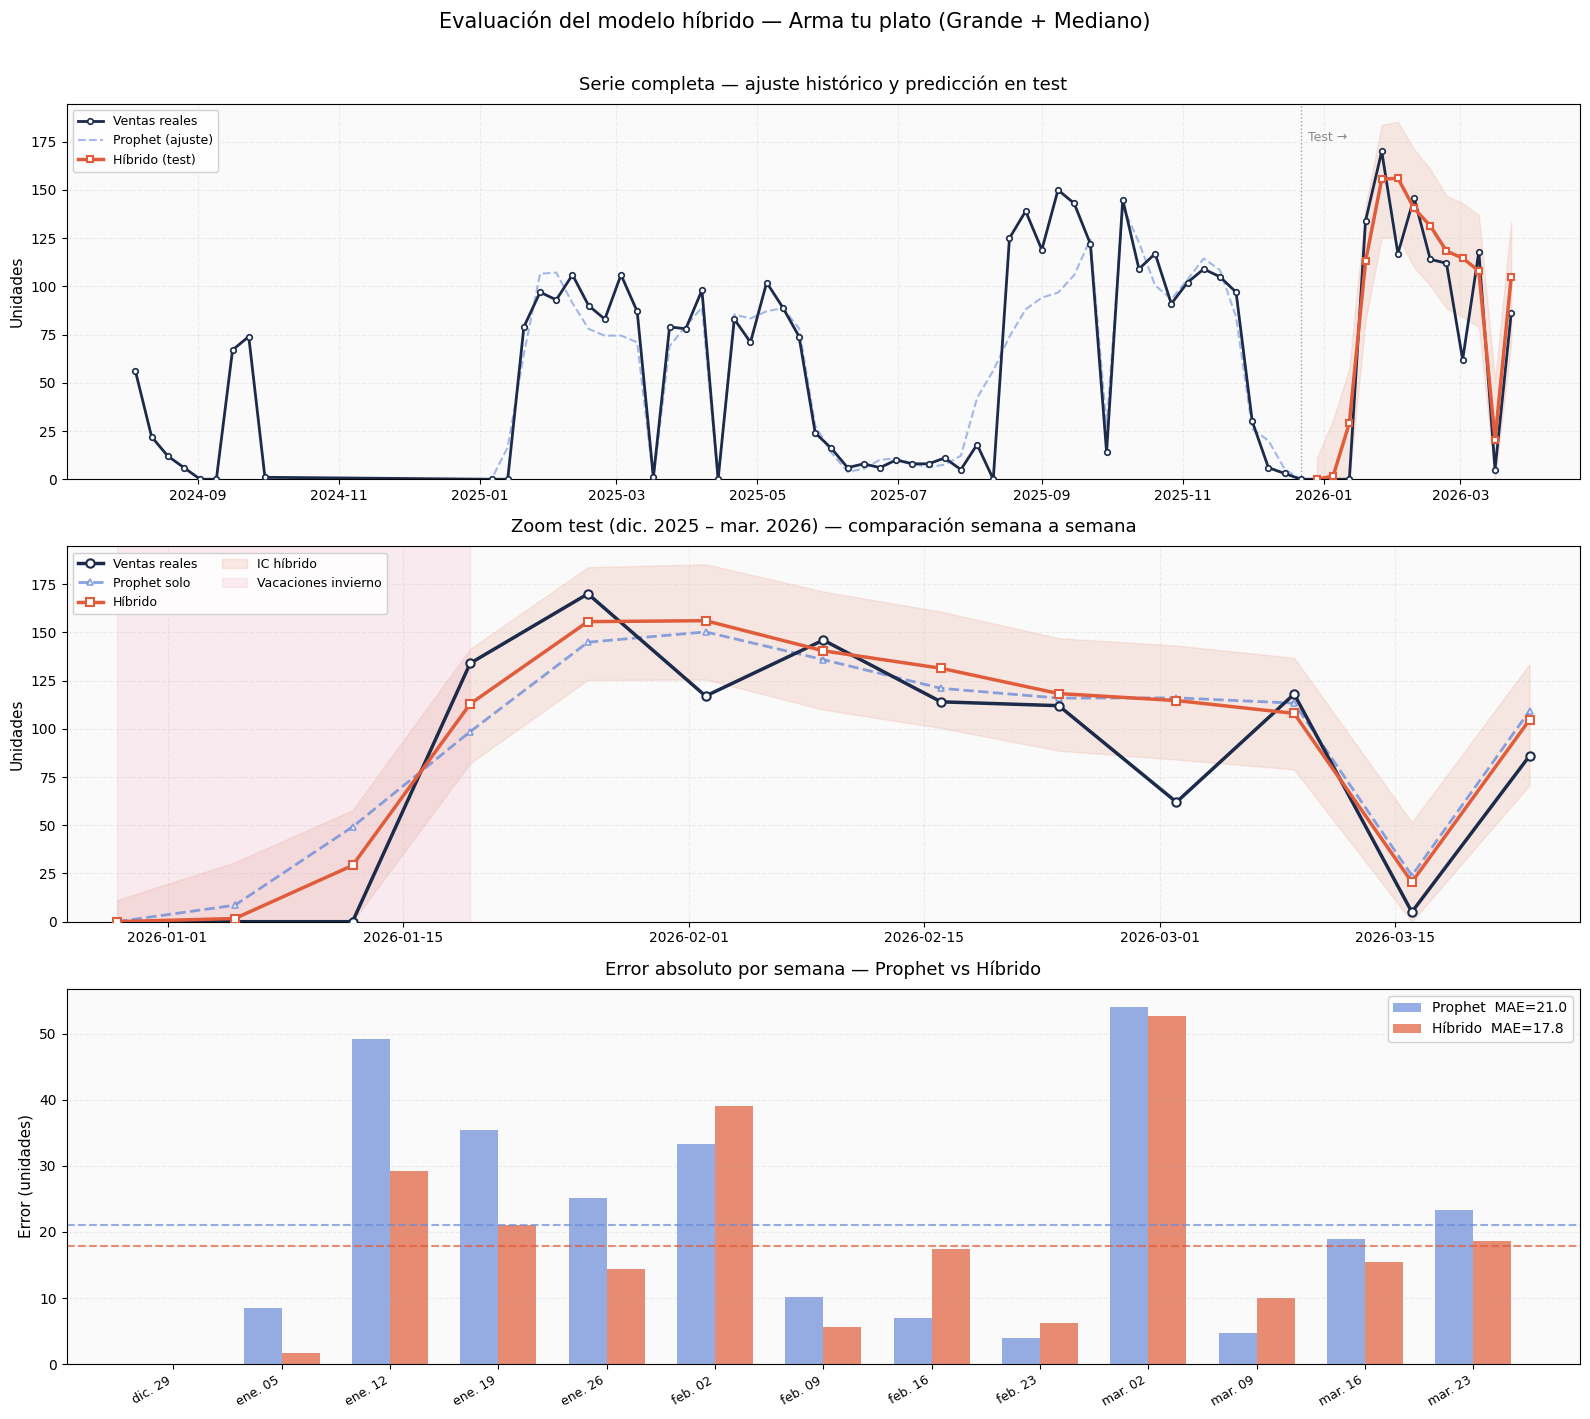

In [179]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)

# ── Colores ────────────────────────────────────────────────────────
COLOR_REAL    = '#1C2B4A'
COLOR_PROPHET = '#6B8CDA'
COLOR_HIBRIDO = '#E05C3A'
COLOR_BANDA   = '#E05C3A'

# ── Rango dinámico del test ────────────────────────────────────────
fecha_ini_test = test_h['ds'].min()
fecha_fin_test = test_h['ds'].max()
label_rango    = f"{fecha_ini_test.strftime('%b %Y')} – {fecha_fin_test.strftime('%b %Y')}"

# ── Periodos especiales a sombrear (solo si caen dentro del test) ──
periodos = [
    ('Exámenes dic',        pd.Timestamp('2025-12-01'), pd.Timestamp('2025-12-20'), '#5AAED4'),
    ('Vacaciones invierno', pd.Timestamp('2025-12-22'), pd.Timestamp('2026-01-19'), '#ED93B1'),
    ('Semana Santa',        pd.Timestamp('2026-03-29'), pd.Timestamp('2026-04-05'), '#F4C97A'),
]

# ══════════════════════════════════════════════════════════════════
# Panel 1 — Serie completa
# ══════════════════════════════════════════════════════════════════
ax1 = axes[0]

ax1.plot(serie_combinada['ds'], serie_combinada['y'],
         color=COLOR_REAL, linewidth=2, marker='o', markersize=4,
         markerfacecolor='white', markeredgecolor=COLOR_REAL,
         markeredgewidth=1.2, zorder=4, label='Ventas reales')

ax1.plot(train_h['ds'], train_h['yhat'].clip(0),
         color=COLOR_PROPHET, linewidth=1.5, linestyle='--',
         alpha=0.6, zorder=2, label='Prophet (ajuste)')

ax1.plot(test_h['ds'], pred_hibrida,
         color=COLOR_HIBRIDO, linewidth=2.5,
         marker='s', markersize=5,
         markerfacecolor='white', markeredgecolor=COLOR_HIBRIDO,
         markeredgewidth=1.5, zorder=4, label='Híbrido (test)')

ax1.fill_between(test_h['ds'],
                 (test_h['yhat_lower'] + modelo_xgb_h.predict(X_test_h)).clip(0),
                 (test_h['yhat_upper'] + modelo_xgb_h.predict(X_test_h)).clip(0),
                 color=COLOR_BANDA, alpha=0.12, zorder=1)

ax1.axvline(train_h['ds'].max(), color='#888888', linewidth=1, linestyle=':', alpha=0.8)
ax1.text(train_h['ds'].max() + pd.Timedelta(days=3),
         ax1.get_ylim()[1] * 0.9, 'Test →', fontsize=9, color='#888888')

ax1.set_title('Serie completa — ajuste histórico y predicción en test',
              fontsize=13, pad=10)
ax1.set_ylabel('Unidades', fontsize=11)
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.set_facecolor('#FAFAFA')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)

# ══════════════════════════════════════════════════════════════════
# Panel 2 — Zoom en periodo de test
# ══════════════════════════════════════════════════════════════════
ax2 = axes[1]

ax2.plot(test_h['ds'], y_test_real.values,
         color=COLOR_REAL, linewidth=2.5, marker='o', markersize=6,
         markerfacecolor='white', markeredgecolor=COLOR_REAL,
         markeredgewidth=1.5, zorder=4, label='Ventas reales')

ax2.plot(test_h['ds'], test_h['yhat'].clip(0),
         color=COLOR_PROPHET, linewidth=2, linestyle='--',
         marker='^', markersize=5,
         markerfacecolor='white', markeredgecolor=COLOR_PROPHET,
         markeredgewidth=1.2, alpha=0.8, zorder=3, label='Prophet solo')

ax2.plot(test_h['ds'], pred_hibrida,
         color=COLOR_HIBRIDO, linewidth=2.5,
         marker='s', markersize=6,
         markerfacecolor='white', markeredgecolor=COLOR_HIBRIDO,
         markeredgewidth=1.5, zorder=4, label='Híbrido')

ax2.fill_between(test_h['ds'],
                 (test_h['yhat_lower'] + modelo_xgb_h.predict(X_test_h)).clip(0),
                 (test_h['yhat_upper'] + modelo_xgb_h.predict(X_test_h)).clip(0),
                 color=COLOR_BANDA, alpha=0.12, zorder=1, label='IC híbrido')

# Sombrear solo los periodos que caen dentro del rango del test
for nombre, inicio, fin, color in periodos:
    if inicio <= fecha_fin_test and fin >= fecha_ini_test:
        ax2.axvspan(max(inicio, fecha_ini_test), min(fin, fecha_fin_test),
                    color=color, alpha=0.15, label=nombre)

ax2.set_xlim(fecha_ini_test - pd.Timedelta(days=3),
             fecha_fin_test + pd.Timedelta(days=3))
ax2.set_title(f'Zoom test ({label_rango}) — comparación semana a semana',
              fontsize=13, pad=10)
ax2.set_ylabel('Unidades', fontsize=11)
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.set_facecolor('#FAFAFA')
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2)

# ══════════════════════════════════════════════════════════════════
# Panel 3 — Error absoluto semana a semana
# ══════════════════════════════════════════════════════════════════
ax3 = axes[2]

error_prophet = abs(y_test_real.values - test_h['yhat'].clip(0).values)
error_hibrido = abs(y_test_real.values - pred_hibrida.values)

x     = np.arange(len(test_h))
ancho = 0.35

ax3.bar(x - ancho/2, error_prophet, ancho,
        color=COLOR_PROPHET, alpha=0.7, label=f'Prophet  MAE={error_prophet.mean():.1f}')
ax3.bar(x + ancho/2, error_hibrido, ancho,
        color=COLOR_HIBRIDO, alpha=0.7, label=f'Híbrido  MAE={error_hibrido.mean():.1f}')

ax3.axhline(error_prophet.mean(), color=COLOR_PROPHET, linewidth=1.5, linestyle='--', alpha=0.7)
ax3.axhline(error_hibrido.mean(), color=COLOR_HIBRIDO, linewidth=1.5, linestyle='--', alpha=0.7)

ax3.set_xticks(x)
ax3.set_xticklabels([d.strftime('%b %d') for d in test_h['ds']],
                    rotation=30, ha='right', fontsize=9)
ax3.set_title('Error absoluto por semana — Prophet vs Híbrido',
              fontsize=13, pad=10)
ax3.set_ylabel('Error (unidades)', fontsize=11)
ax3.grid(True, alpha=0.2, linestyle='--', axis='y')
ax3.set_facecolor('#FAFAFA')
ax3.legend(fontsize=10, framealpha=0.9)

# ══════════════════════════════════════════════════════════════════
fig.suptitle('Evaluación del modelo híbrido — Arma tu plato (Grande + Mediano)',
             fontsize=15, fontweight='500', y=1.01)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


In [ ]:
df_comparacion = pd.DataFrame({
    'ds'      : serie_combinada['ds'].iloc[-13:].values,
    'real'    : y_test_real.values,
    'hibrido' : pred_hibrida.values
})

df_comparacion['error_abs'] = abs(df_comparacion['real'] - df_comparacion['hibrido']).round(1)
df_comparacion['error_pct'] = (df_comparacion['error_abs'] / df_comparacion['real'].replace(0, np.nan) * 100).round(1)

# Contexto académico Uniandes 2026-I
calendario = {
    '2025-12-29': 'Vacaciones invierno',
    '2026-01-05': 'Vacaciones invierno',
    '2026-01-12': 'Vacaciones invierno',
    '2026-01-19': 'Semana 1',
    '2026-01-26': 'Semana 2',
    '2026-02-02': 'Semana 3',
    '2026-02-09': 'Semana 4',
    '2026-02-16': 'Semana 5',
    '2026-02-23': 'Semana 6',
    '2026-03-02': 'Semana 7',
    '2026-03-09': 'Semana 8',
    '2026-03-16': 'Semana de receso',
    '2026-03-23': 'Semana 9',
}

df_comparacion['contexto'] = df_comparacion['ds'].astype(str).str[:10].map(calendario)

df_comparacion


,ds,real,hibrido,error_abs,error_pct,contexto
0,2025-12-29,0.0,0.000000,0.0,NaN,Vacaciones invierno
1,2026-01-05,0.0,1.649657,1.6,NaN,Vacaciones invierno
2,2026-01-12,0.0,29.158311,29.2,NaN,Vacaciones invierno
3,2026-01-19,134.0,112.950235,21.0,15.7,Semana 1
4,2026-01-26,170.0,155.580453,14.4,8.5,Semana 2
5,2026-02-02,117.0,156.076327,39.1,33.4,Semana 3
6,2026-02-09,146.0,140.453413,5.5,3.8,Semana 4
7,2026-02-16,114.0,131.399863,17.4,15.3,Semana 5
8,2026-02-23,112.0,118.282964,6.3,5.6,Semana 6
9,2026-03-02,62.0,114.662013,52.7,85.0,Semana 7


---

## Análisis de Autocorrelación (ACF / PACF)

Se analiza si los residuos del modelo híbrido contienen estructura no capturada:

- **ACF** (*Autocorrelation Function*): mide correlación del residuo con sus propios rezagos. Picos significativos indican que el error no es ruido blanco — hay información predecible que el modelo está dejando pasar.
- **PACF** (*Partial ACF*): muestra la correlación directa de cada rezago eliminando el efecto de los intermedios. Útil para diagnosticar qué lag específico agregar.
- **Test de Ljung-Box**: hipótesis nula = residuos son ruido blanco. Si p-value < 0.05 → hay autocorrelación en los errores → el modelo se puede mejorar.

También se analiza el ACF/PACF de la **serie original** para entender la estructura de dependencia temporal de las ventas.

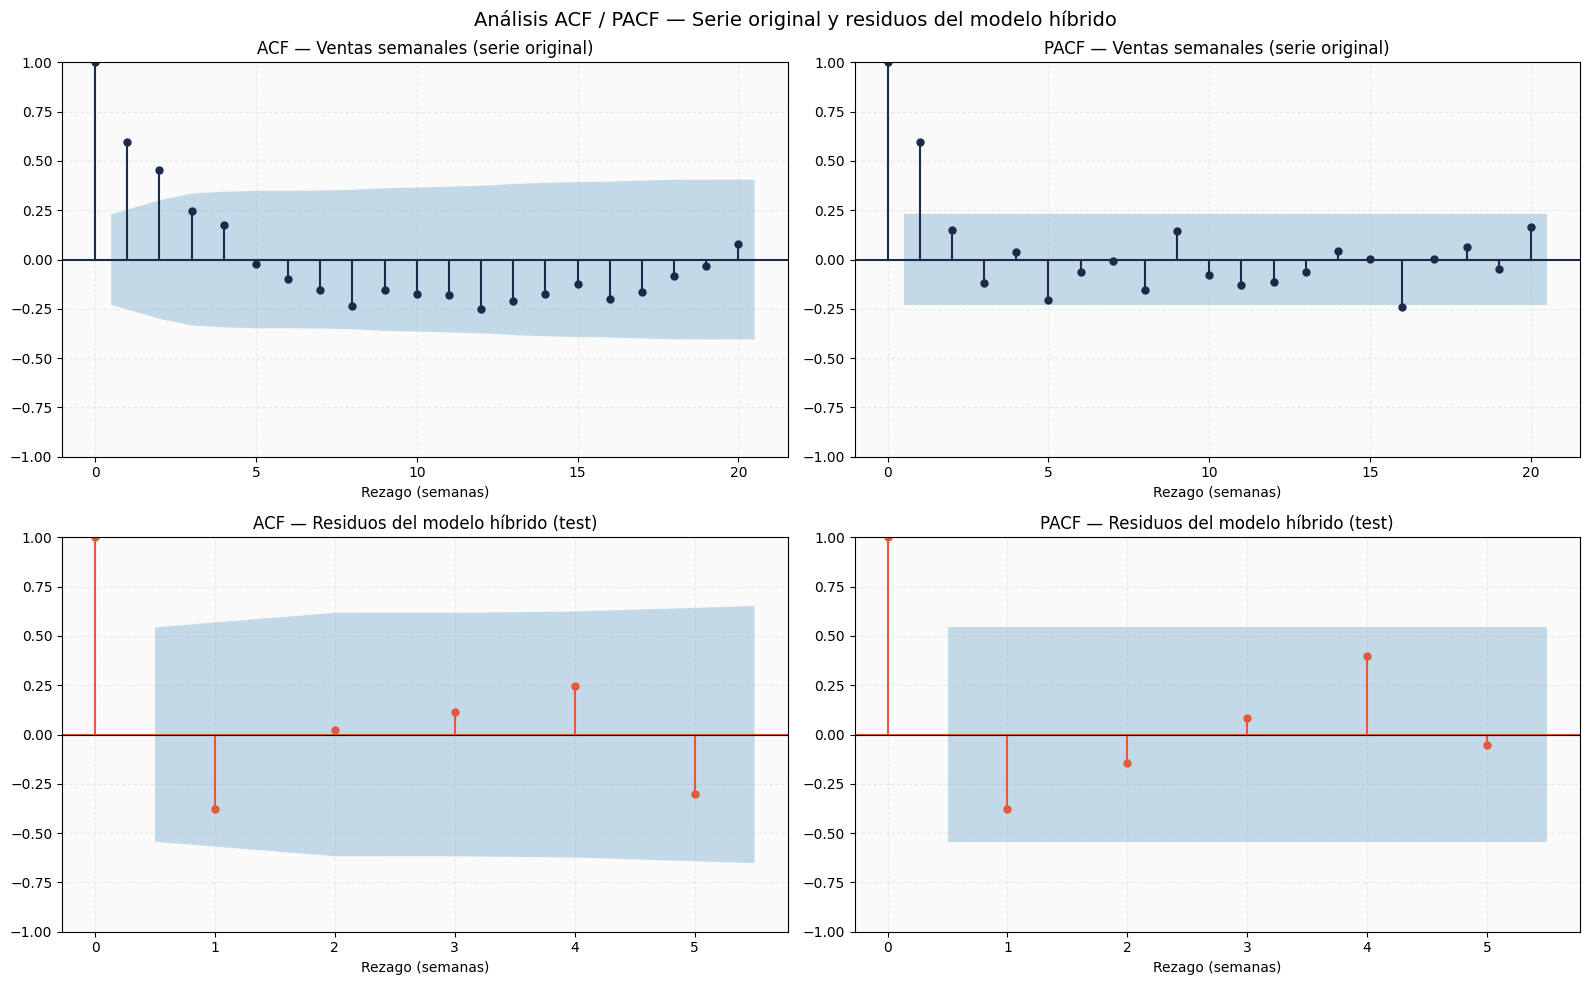

TEST DE LJUNG-BOX — Residuos del modelo híbrido
H0: los residuos son ruido blanco (sin autocorrelación)
Rechazar H0 si p-value < 0.05
     estadístico   p-value      conclusión
lag                                       
1       2.346729  0.125546  ✅ Ruido blanco
2       2.355577  0.307959  ✅ Ruido blanco
3       2.613614  0.455108  ✅ Ruido blanco
4       3.933070  0.415140  ✅ Ruido blanco
5       6.179375  0.289154  ✅ Ruido blanco
Resumen: 0/5 lags con autocorrelación significativa (p < 0.05)
→ Los residuos no muestran autocorrelación. El modelo captura bien la estructura temporal.


In [114]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

# ── Residuos del modelo híbrido (serie completa de entrenamiento + test) ────
# Usamos los residuos del test set; si quieres más puntos, usa los de Prophet CV
residuos = (y_test_real.values - pred_hibrida.values).astype(float)
serie_y  = serie_combinada.set_index("ds")["y"].astype(float)

lags_max = min(15, len(residuos) // 2 - 1)  # máximo de lags válidos para la muestra

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Análisis ACF / PACF — Serie original y residuos del modelo híbrido",
             fontsize=14, fontweight="500")

# ── Panel 1: ACF de la serie original ───────────────────────────────────────
plot_acf(serie_y.dropna(), lags=20, alpha=0.05, ax=axes[0, 0],
         color="#1C2B4A", vlines_kwargs={"colors": "#1C2B4A"})
axes[0, 0].set_title("ACF — Ventas semanales (serie original)", fontsize=12)
axes[0, 0].set_xlabel("Rezago (semanas)")
axes[0, 0].set_facecolor("#FAFAFA")
axes[0, 0].grid(True, alpha=0.2, linestyle="--")

# ── Panel 2: PACF de la serie original ──────────────────────────────────────
plot_pacf(serie_y.dropna(), lags=20, alpha=0.05, method="ywm", ax=axes[0, 1],
          color="#1C2B4A", vlines_kwargs={"colors": "#1C2B4A"})
axes[0, 1].set_title("PACF — Ventas semanales (serie original)", fontsize=12)
axes[0, 1].set_xlabel("Rezago (semanas)")
axes[0, 1].set_facecolor("#FAFAFA")
axes[0, 1].grid(True, alpha=0.2, linestyle="--")

# ── Panel 3: ACF de residuos del híbrido ────────────────────────────────────
plot_acf(residuos, lags=lags_max, alpha=0.05, ax=axes[1, 0],
         color="#E05C3A", vlines_kwargs={"colors": "#E05C3A"})
axes[1, 0].set_title("ACF — Residuos del modelo híbrido (test)", fontsize=12)
axes[1, 0].set_xlabel("Rezago (semanas)")
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_facecolor("#FAFAFA")
axes[1, 0].grid(True, alpha=0.2, linestyle="--")

# ── Panel 4: PACF de residuos del híbrido ───────────────────────────────────
plot_pacf(residuos, lags=lags_max, alpha=0.05, method="ywm", ax=axes[1, 1],
          color="#E05C3A", vlines_kwargs={"colors": "#E05C3A"})
axes[1, 1].set_title("PACF — Residuos del modelo híbrido (test)", fontsize=12)
axes[1, 1].set_xlabel("Rezago (semanas)")
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_facecolor("#FAFAFA")
axes[1, 1].grid(True, alpha=0.2, linestyle="--")

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# ── Test de Ljung-Box sobre residuos ────────────────────────────────────────
print("\
" + "="*55)
print("TEST DE LJUNG-BOX — Residuos del modelo híbrido")
print("="*55)
print("H0: los residuos son ruido blanco (sin autocorrelación)")
print("Rechazar H0 si p-value < 0.05\
")

lb = acorr_ljungbox(residuos, lags=list(range(1, lags_max + 1)), return_df=True)
lb.index.name = "lag"
lb.columns = ["estadístico", "p-value"]
lb["conclusión"] = lb["p-value"].apply(
    lambda p: "❌ Autocorrelación detectada" if p < 0.05 else "✅ Ruido blanco"
)
print(lb.to_string())

# Resumen ejecutivo
n_sig = (lb["p-value"] < 0.05).sum()
print(f"\
Resumen: {n_sig}/{lags_max} lags con autocorrelación significativa (p < 0.05)")
if n_sig > 0:
    lags_sig = lb[lb["p-value"] < 0.05].index.tolist()
    print(f"Lags significativos: {lags_sig}")
    print("→ Considerar agregar estos lags como features en XGBoost.")
else:
    print("→ Los residuos no muestran autocorrelación. El modelo captura bien la estructura temporal.")


---

## Optimización de hiperparámetros con Optuna

Búsqueda bayesiana sobre el espacio de hiperparámetros del XGBoost corrector de residuos.
Se usa **TimeSeriesSplit (3 folds)** para respetar el orden temporal y evitar data leakage.

**Objetivo:** minimizar MAE de `yhat_prophet + corrección_xgboost` vs ventas reales en validación interna.

> Instalar si es necesario: `pip install optuna`

In [ ]:
import optuna
from sklearn.model_selection import TimeSeriesSplit
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 80  # aumentar para mayor exhaustividad

X_opt   = train_h[FEATURES_HIBRIDO].values
y_res   = train_h['residuo'].values
y_real  = train_h['y'].values
yhat_tr = train_h['yhat'].values

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators',      100, 600),
        learning_rate     = trial.suggest_float('learning_rate',   0.01, 0.25, log=True),
        max_depth         = trial.suggest_int('max_depth',         2, 7),
        subsample         = trial.suggest_float('subsample',       0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree',0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight',  1, 15),
        reg_alpha         = trial.suggest_float('reg_alpha',       0.0, 2.0),
        reg_lambda        = trial.suggest_float('reg_lambda',      0.5, 5.0),
        random_state=42, n_jobs=-1, verbosity=0
    )

    tscv = TimeSeriesSplit(n_splits=3)
    fold_maes = []

    for tr_idx, val_idx in tscv.split(X_opt):
        X_tr, X_val = X_opt[tr_idx], X_opt[val_idx]
        y_tr        = y_res[tr_idx]
        y_val_real  = y_real[val_idx]
        yhat_val    = yhat_tr[val_idx]

        m = XGBRegressor(**params)
        m.fit(X_tr, y_tr, verbose=False)

        pred_val = (yhat_val + m.predict(X_val)).clip(0)
        fold_maes.append(mean_absolute_error(y_val_real, pred_val))

    return float(np.mean(fold_maes))


study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\
Mejor MAE (CV interno): {study.best_value:.2f}")
print("Mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:<22} = {v}")


In [ ]:
# ── Reentrenar con hiperparámetros óptimos ────────────────────────
best = study.best_params

modelo_xgb_h_opt = XGBRegressor(
    n_estimators     = best['n_estimators'],
    learning_rate    = best['learning_rate'],
    max_depth        = best['max_depth'],
    subsample        = best['subsample'],
    colsample_bytree = best['colsample_bytree'],
    min_child_weight = best['min_child_weight'],
    reg_alpha        = best['reg_alpha'],
    reg_lambda       = best['reg_lambda'],
    random_state=42, n_jobs=-1
)
modelo_xgb_h_opt.fit(X_train_h, y_train_residuo, verbose=False)

correccion_opt   = modelo_xgb_h_opt.predict(X_test_h)
pred_hibrida_opt = (test_h['yhat'] + correccion_opt).clip(0)

# ── Comparación antes / después ───────────────────────────────────
smape_fn = lambda y, yhat: (2 * np.abs(y - yhat) / (np.abs(y) + np.abs(yhat) + 1e-8)).mean()

mae_base   = mean_absolute_error(y_test_real, pred_hibrida)
mae_opt    = mean_absolute_error(y_test_real, pred_hibrida_opt)
smape_base = smape_fn(y_test_real.values, pred_hibrida.values)
smape_opt  = smape_fn(y_test_real.values, pred_hibrida_opt.values)

print(f"{'':35} {'MAE':>8} {'SMAPE':>8}")
print("-" * 55)
print(f"{'Híbrido (params manuales)':<35} {mae_base:>8.1f} {smape_base:>8.3f}")
print(f"{'Híbrido (Optuna)':<35} {mae_opt:>8.1f} {smape_opt:>8.3f}")
delta_mae   = mae_opt - mae_base
delta_smape = smape_opt - smape_base
print("-" * 55)
print(f"{'Mejora':<35} {delta_mae:>+8.1f} {delta_smape:>+8.3f}")

if mae_opt < mae_base:
    modelo_xgb_h = modelo_xgb_h_opt
    pred_hibrida = pred_hibrida_opt
    print("\
→ modelo_xgb_h actualizado con hiperparámetros Optuna.")
else:
    print("\
→ Los parámetros manuales siguen siendo mejores en test. Se conserva el modelo original.")

# ── Visualización ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_h['ds'], y_test_real.values,
        color='#1C2B4A', linewidth=2.5, marker='o', markersize=6,
        markerfacecolor='white', markeredgecolor='#1C2B4A', label='Real')
ax.plot(test_h['ds'], pred_hibrida.values,
        color='#E05C3A', linewidth=2, linestyle='--', marker='s', markersize=5,
        markerfacecolor='white', label=f'Híbrido manual   MAE={mae_base:.1f}')
ax.plot(test_h['ds'], pred_hibrida_opt.values,
        color='#2CA02C', linewidth=2, marker='^', markersize=5,
        markerfacecolor='white', label=f'Híbrido Optuna   MAE={mae_opt:.1f}')
ax.set_title('Comparación: hiperparámetros manuales vs Optuna (test set)', fontsize=13)
ax.set_ylabel('Unidades', fontsize=11)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_facecolor('#FAFAFA')
ax.legend(fontsize=10, framealpha=0.9)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()
